# 12 -- MegaStacking

## Что здесь происходит

Идея stacking простая:

```text
                     CatBoost direct
                           \
                            \
                 Joint Hurdle BiLSTM ----\
                            /              \
                           /                -> level-1 OOF -> meta-model -> pred_log
                  two-stage LightGBM -----/
                           \
                            \
                      Random Forest
```

Base models не обучаются на одном и том же validation target. Для каждого cutoff строю честный temporal OOF:

```text
Aug <- train <= Jul
Sep <- train <= Aug
Oct <- train <= Sep
Nov <- train <= Oct
Dec <- train <= Nov
Jan <- train <= Dec
```

После этого у каждого `(user_id, cutoff)` есть предсказания всех base models. Они и становятся признаками meta-model.

Все основные prediction и target переведены в `log1p`:

`target_log = log1p(target_gmv_30d)`.

Поэтому RMSE в этом пространстве совпадает с RMSLE исходного GMV.

---

## Base models

### 1. CatBoost direct

Один direct boosting -- второй direct boosting на тех же tabular features здесь не нужен.

Признаки:

- 91 numeric feature из `Prepared_data.parquet`;
- `user_id` отдельно как categorical feature.

Параметры:

```text
iterations=900
learning_rate=0.03
depth=8
l2_leaf_reg=8.0
random_strength=0.5
random_seed=143
thread_count=-1
```

Target:

`log1p(GMV_30d)`.

### 2. Two-stage LightGBM

Модель отдельно решает две задачи:

```text
classifier -> P(GMV > 0)
regressor  -> log1p(GMV) | GMV > 0

pred_log = scale * p_nonzero**gamma * positive_log
```

Если exact temporal OOF из `notebooks/two_stage/` найден -- используется он.

В этом запуске exact OOF не нашелся, поэтому two-stage был обучен прямо здесь. Extractor также не вытащил exact params/feature list из notebook тиммейта -- использовались fallback params и все 91 numeric feature.

Classifier:

```text
n_estimators=700
learning_rate=0.03
num_leaves=63
min_child_samples=40
subsample=0.90
colsample_bytree=0.90
reg_alpha=0.10
reg_lambda=2.5
random_state=1337
n_jobs=-1
```

Regressor -- те же основные параметры, `n_estimators=800`, `random_state=1338`.

`gamma/scale` калибруются nested temporal способом: только на последнем cutoff внутри train, текущий validation cutoff для calibration не используется.

LightGBM запускается в отдельном subprocess -- native crash не должен убить kernel с PyTorch.

### 3. Joint Hurdle BiLSTM v4

Текущая сильная LSTM, без изменений относительно `07_LSTM.ipynb`.

Входы:

- 90 дней истории;
- 53 sequence feature на день;
- 93 short-summary feature;
- 235 static feature после log/missing-mask augmentation.

Архитектура:

```text
sequence
    -> Linear(80) + LayerNorm + GELU
    -> 2-layer BiLSTM(hidden=112)
    -> last / mean / max / attention
    -> sequence head (144)
                              \
short summary (93) -> MLP (64) -> concat -> fusion (96)
                              /
static (235) -> MLP (96)     /
                                         |
                         +---------------+---------------+
                         |               |               |
                     gate_head      positive_head    direct_head
                         |               |               |
                    P(GMV > 0)      positive_log      direct_log
                         \              /
                          -> hurdle_log
                                \
                                 -> learned blend -> pred_log
                                /
                         direct_log
```

Основные параметры:

```text
d_model=80
hidden_size=112
num_layers=2
lstm_dropout=0.25
head_dropout=0.35
batch_size=768
epochs=6
lr=3.5e-4
weight_decay=1.2e-3
seed=42
```

`user embedding=False`, `conv stem=False`, `future calendar static=False`.

Всего `851,216` параметров.

### 4. Random Forest

Нужен не как standalone winner, а как bagging-модель с другими ошибками.

Признаки -- те же 91 numeric feature.

```text
n_estimators=120
max_depth=18
min_samples_leaf=25
max_features=0.50
max_samples=0.35
random_state=4242
n_jobs=-1
```

---

## Какие признаки получает meta-model

Meta-model **не видит исходные user features**. Только честные OOF predictions base models и простые disagreement features.

В этом запуске получилось 22 meta-feature.

Base predictions:

```text
pred_cat
pred_lstm
pred_lstm_direct
pred_lstm_hurdle
pred_two_stage
pred_rf
```

Cross-hurdle predictions:

```text
pred_cross_lstm_gate_two_m = lstm_gate * two_stage_positive
pred_cross_two_gate_lstm_m = two_stage_gate * lstm_positive
```

То есть отдельно проверяется гипотеза: может ли gate одной hurdle-модели лучше работать с оценкой размера покупки другой.

Агрегаты по prediction:

```text
meta_mean
meta_std
meta_min
meta_max
meta_range
```

Disagreement:

```text
meta_lstm_minus_cat
meta_lstm_minus_two_stage
meta_cat_minus_two_stage
meta_rf_minus_mean
```

Gate features:

```text
lstm_gate
two_stage_gate
meta_gate_mean
meta_gate_diff
meta_gate_abs_diff
```

---

## Как выбирается meta-model

Проверяются:

```text
LinearRegression
positive LinearRegression
Ridge
ElasticNet
constrained convex blend
```

Meta-CV тоже temporal:

```text
Oct <- meta train Aug+Sep
Nov <- meta train Aug+Sep+Oct
Dec <- meta train Aug+Sep+Oct+Nov
Jan <- meta train Aug+Sep+Oct+Nov+Dec
```

Для каждого варианта считаю:

```text
selection_score =
    mean_RMSLE
    + 0.35 * std_RMSLE
    + 0.20 * max(worst_gap_vs_best_base, 0)
```

То есть выбирается не просто случайный minimum на одном месяце -- штрафую нестабильность и плохой worst-case.

Победитель этого запуска:

```text
ElasticNet
alpha=0.03
l1_ratio=0.20
recency_factor=1.0
max_iter=30000
tol=1e-4
```

`recency_factor=1.0` -- дополнительное усиление последних cutoff не понадобилось.

После выбора ElasticNet переобучается на всех шести OOF cutoff и используется для February prediction.

---

## Leakage

Схема специально сделана так, чтобы target будущего cutoff не попадал назад:

- base model для cutoff `T` обучается только на cutoff `< T`;
- two-stage `gamma/scale` для `T` калибруются только внутри train period;
- meta для cutoff `T` обучается только на более ранних OOF cutoff;
- raw target не является meta-feature;
- final base models обучаются на всех labeled cutoff только после завершения temporal validation.

Это не random KFold по panel-строкам -- один и тот же будущий месяц не смешивается между train/valid.

In [21]:
from pathlib import Path
import hashlib
import json
import math
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import ConcatDataset, DataLoader, Dataset


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "lstm" / "meta.json").exists():
            return path
    raise FileNotFoundError(
        "Не найден data/lstm/meta.json. Сначала запустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lstm"
MODEL_DIR = PROJECT_ROOT / "models" / "lstm_hurdle_v4_robust"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "meta.json", encoding="utf-8") as f:
    META = json.load(f)

if META.get("format_version") != 2:
    raise RuntimeError(
        "LSTM v4 ожидает data format v2. Перезапустите обновленный 06_LSTM_Data_Preparation.ipynb."
    )

LABELED_CUTOFFS = META["labeled_cutoffs"]
INFERENCE_CUTOFF = META["inference_cutoff"]
BASE_SEQUENCE_FEATURES = META["base_sequence_features"]
CALENDAR_FEATURES = META["calendar_sequence_features"]
RAW_STATIC_FEATURES = META["static_features"]
RAW_STATIC_LOG_FEATURES = META["static_log_copy_features"]
EXTRA_STATIC_FEATURES = set(META.get("extra_static_features", []))
SEQ_LEN = int(META["seq_len"])
N_USERS = int(META["user_count"])

BASE_INDEX = {name: i for i, name in enumerate(BASE_SEQUENCE_FEATURES)}

# Флаги меняю по одному после baseline run.
USE_USER_EMBEDDING = False
USER_EMBED_DIM = 4
USE_CONV_STEM = False

USE_ABSOLUTE_TIME = True
USE_FUTURE_CALENDAR_STATIC = False
USE_CUTOFF_SEASONAL_STATIC = False

BATCH_SIZE = 768
MAX_CV_EPOCHS = 6
N_CV_FOLDS = 3
LR = 3.5e-4
EMBED_LR = 1.0e-4
WEIGHT_DECAY = 1.2e-3
EMBED_WEIGHT_DECAY = 8e-3
RANDOM_STATE = 42
FINAL_SEEDS = [42, 143]

AUX_GATE_WEIGHT = 0.03
AUX_POS_WEIGHT = 0.10
AUX_DIRECT_WEIGHT = 0.05

REFERENCE_JAN_HOLDOUT_RMSLE = 1.679061
AUTO_SKIP_FINAL_IF_WEAK = True
MAX_JAN_DEGRADATION_FOR_FINAL = 0.015
FORCE_FINAL_TRAIN = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
NUM_WORKERS = 4 if DEVICE.type == "cuda" else 0
USE_AMP = DEVICE.type == "cuda"


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_static_features():
    selected = []
    for name in RAW_STATIC_FEATURES:
        if name not in EXTRA_STATIC_FEATURES:
            selected.append(name)
            continue

        if name == "cutoff_time_years" and USE_ABSOLUTE_TIME:
            selected.append(name)
        elif name.startswith("forecast_") and USE_FUTURE_CALENDAR_STATIC:
            selected.append(name)
        elif (
            name.startswith("cutoff_")
            and name != "cutoff_time_years"
            and USE_CUTOFF_SEASONAL_STATIC
        ):
            selected.append(name)
    return selected


STATIC_FEATURES = choose_static_features()
STATIC_INDICES = np.array(
    [RAW_STATIC_FEATURES.index(name) for name in STATIC_FEATURES],
    dtype=np.int64,
)
STATIC_LOG_FEATURES = [name for name in RAW_STATIC_LOG_FEATURES if name in STATIC_FEATURES]
STATIC_LOG_INDICES = [STATIC_FEATURES.index(name) for name in STATIC_LOG_FEATURES]

set_seed()
print("device:", DEVICE)
print("AMP:", USE_AMP)
print("labeled cutoffs:", LABELED_CUTOFFS)
print("CV validation cutoffs:", LABELED_CUTOFFS[-N_CV_FOLDS:])
print("inference:", INFERENCE_CUTOFF)
print("users:", N_USERS)
print("static features:", len(STATIC_FEATURES), "/", len(RAW_STATIC_FEATURES))
print("user embedding:", USE_USER_EMBEDDING)
print("future calendar static:", USE_FUTURE_CALENDAR_STATIC)

# ============================================================================
# MegaStacking config
# ============================================================================

import ast
import gc
import os
import re
import subprocess
import sys
import time
import warnings

import joblib
from catboost import CatBoostRegressor
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PREPARED_PATH = PROJECT_ROOT / "data" / "Prepared_data.parquet"
SAMPLE_SUBMIT_PATH = PROJECT_ROOT / "data" / "sample_submit.csv"

STACK_DIR = PROJECT_ROOT / "models" / "temporal_stacking_max"
OOF_DIR = STACK_DIR / "oof"
TEST_DIR = STACK_DIR / "test_level1"
PLOT_DIR = STACK_DIR / "plots"
TWO_STAGE_DIR = STACK_DIR / "two_stage"
CACHE_VERSION = 3

for path in [STACK_DIR, OOF_DIR, TEST_DIR, PLOT_DIR, TWO_STAGE_DIR, SUBMISSION_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OOF_VALID_CUTOFFS = LABELED_CUTOFFS[-6:]
META_VALID_CUTOFFS = OOF_VALID_CUTOFFS[-4:]

# 6 эпох оставляю намеренно.
# Текущий лучший public, January OOF и существующие LSTM cache построены на 6 эпохах.
# Увеличение только внутри stacking создаст train/test mismatch.
LSTM_STACK_SEED = 42
LSTM_STACK_EPOCHS = 6

USE_RF = True
USE_CROSS_HURDLE = True

TEAMMATE_NOTEBOOK = PROJECT_ROOT / "notebooks" / "two_stage" / "09_Two_Staged_Model.ipynb"

CAT_DIRECT_PARAMS = {
    "loss_function": "RMSE",
    "iterations": 900,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 8.0,
    "random_strength": 0.5,
    "random_seed": 143,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
}

RF_PARAMS = {
    "n_estimators": 120,
    "max_depth": 18,
    "min_samples_leaf": 25,
    "max_features": 0.50,
    "max_samples": 0.35,
    "n_jobs": -1,
    "random_state": 4242,
    "verbose": 0,
}

# Fallback только если best params не получилось извлечь из notebook/artifacts.
TWO_STAGE_CLASSIFIER_FALLBACK = {
    "objective": "binary",
    "n_estimators": 700,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "min_child_samples": 40,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.10,
    "reg_lambda": 2.5,
    "random_state": 1337,
    "n_jobs": -1,
    "verbosity": -1,
}

TWO_STAGE_REGRESSOR_FALLBACK = {
    "objective": "regression",
    "n_estimators": 800,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "min_child_samples": 40,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.10,
    "reg_lambda": 2.5,
    "random_state": 1338,
    "n_jobs": -1,
    "verbosity": -1,
}

META_RECENCY_FACTORS = [1.0, 1.15, 1.30, 1.50]
RIDGE_ALPHAS = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

# вместо текущего ELASTICNET_GRID
ELASTICNET_GRID = [
    (0.01, 0.05),
    (0.01, 0.20),
    (0.03, 0.05),
    (0.03, 0.20),
    (0.10, 0.05),
    (0.10, 0.20),
]

CONVEX_L2_GRID = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]

print("OOF cutoffs:", OOF_VALID_CUTOFFS)
print("meta validation:", META_VALID_CUTOFFS)
print("device:", DEVICE)
print("stack dir:", STACK_DIR)
print("CatBoost thread_count:", CAT_DIRECT_PARAMS["thread_count"])
print("RF n_jobs:", RF_PARAMS["n_jobs"])
print("two-stage LightGBM default n_jobs:", TWO_STAGE_CLASSIFIER_FALLBACK["n_jobs"])

device: mps
AMP: False
labeled cutoffs: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
CV validation cutoffs: ['2025-11-15', '2025-12-15', '2026-01-14']
inference: 2026-02-13
users: 250000
static features: 92 / 103
user embedding: False
future calendar static: False
OOF cutoffs: ['2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
meta validation: ['2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14']
device: mps
stack dir: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max
CatBoost thread_count: -1
RF n_jobs: -1
two-stage LightGBM default n_jobs: -1


## LSTM v4 -- definitions

Следующие пять code cells просто переносят реализацию текущей LSTM из `07_LSTM.ipynb`.

Зачем они нужны:

- dataset / masks -- корректно работают с разной длиной истории;
- sequence + summary features -- достраивают признаки на батче;
- static preprocessing -- log-transform, missing masks, scaling;
- model -- сама Joint Hurdle BiLSTM;
- train / predict utils -- loss, optimizer, train epoch и inference.

На этом этапе ничего не обучается.

In [2]:
def known_user_mask_from_cutoffs(cutoffs):
    mask = np.zeros(N_USERS, dtype=np.bool_)
    for cutoff in cutoffs:
        idx = np.load(DATA_DIR / cutoff / "user_index.npy", mmap_mode="r")
        mask[np.asarray(idx, dtype=np.int64)] = True
    return mask


class HybridDataset(Dataset):
    def __init__(self, cutoff, with_target=True, known_user_mask=None):
        path = DATA_DIR / cutoff
        self.X = np.load(path / "X.npy", mmap_mode="r")
        self.static = np.load(path / "static.npy", mmap_mode="r")
        self.calendar = np.load(path / "calendar.npy", mmap_mode="r").astype(np.float32)
        self.users = np.load(path / "user_id.npy", mmap_mode="r")
        self.user_index = np.load(path / "user_index.npy", mmap_mode="r")
        self.history_length = np.load(path / "history_length.npy", mmap_mode="r")
        self.y = np.load(path / "y.npy", mmap_mode="r") if with_target else None
        self.known_user_mask = known_user_mask

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        sequence = np.concatenate([
            np.asarray(self.X[i], dtype=np.float32),
            self.calendar,
        ], axis=1)

        user_index = int(self.user_index[i])
        user_known = True if self.known_user_mask is None else bool(self.known_user_mask[user_index])

        raw_static = np.asarray(self.static[i], dtype=np.float32)
        static = raw_static[STATIC_INDICES]

        result = (
            torch.from_numpy(sequence),
            torch.from_numpy(static),
            torch.tensor(user_index, dtype=torch.long),
            torch.tensor(user_known, dtype=torch.bool),
            torch.tensor(int(self.history_length[i]), dtype=torch.long),
        )

        if self.y is None:
            return result

        return (*result, torch.tensor(float(self.y[i]), dtype=torch.float32))


def make_loader(
    cutoffs,
    shuffle=False,
    with_target=True,
    batch_size=BATCH_SIZE,
    known_user_mask=None,
):
    if isinstance(cutoffs, str):
        cutoffs = [cutoffs]

    dataset = ConcatDataset([
        HybridDataset(
            cutoff,
            with_target=with_target,
            known_user_mask=known_user_mask,
        )
        for cutoff in cutoffs
    ])

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=False,
    )

### LSTM -- sequence features

Следующая клетка строит 53 признака на каждый день истории и 93 short-summary признака.

Никакого fit -- только feature construction.

In [3]:
def history_mask_from_lengths(lengths, steps=SEQ_LEN):
    positions = torch.arange(steps, device=lengths.device).unsqueeze(0)
    starts = steps - lengths.unsqueeze(1)
    return positions >= starts


def causal_masked_mean(values, valid_mask, window):
    values = values * valid_mask
    num = F.avg_pool1d(
        F.pad(values.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    den = F.avg_pool1d(
        F.pad(valid_mask.unsqueeze(1), (window - 1, 0)),
        window,
        stride=1,
    ).squeeze(1) * window
    return num / den.clamp_min(1.0)


def first_difference(values, valid_mask):
    previous_valid = F.pad(valid_mask[:, :-1], (1, 0))
    both_valid = valid_mask * previous_valid
    diff = F.pad(values[:, 1:] - values[:, :-1], (1, 0))
    return diff * both_valid


def safe_ratio(numerator, denominator, max_value=5.0):
    ratio = numerator / denominator.clamp_min(1e-3)
    ratio = torch.where(denominator > 0, ratio, torch.zeros_like(ratio))
    return ratio.clamp(0, max_value)


def make_sequence_features(x, lengths):
    steps = x.shape[1]
    valid_mask = history_mask_from_lengths(lengths, steps).float()

    searches_log = x[..., BASE_INDEX["searches"]]
    search_to_cart_log = x[..., BASE_INDEX["search_to_cart"]]
    search_to_ord_log = x[..., BASE_INDEX["search_to_ord"]]
    cat_to_cart_log = x[..., BASE_INDEX["cat_to_cart"]]
    cat_to_ord_log = x[..., BASE_INDEX["cat_to_ord"]]
    to_cart_log = x[..., BASE_INDEX["to_cart"]]
    to_ord_log = x[..., BASE_INDEX["to_ord"]]
    gmv_search_log = x[..., BASE_INDEX["gmv_search"]]
    gmv_log = x[..., BASE_INDEX["gmv"]]
    active = x[..., BASE_INDEX["active"]]

    searches = torch.expm1(searches_log).clamp_min(0)
    search_to_cart = torch.expm1(search_to_cart_log).clamp_min(0)
    search_to_ord = torch.expm1(search_to_ord_log).clamp_min(0)
    cat_to_cart = torch.expm1(cat_to_cart_log).clamp_min(0)
    cat_to_ord = torch.expm1(cat_to_ord_log).clamp_min(0)
    to_cart = torch.expm1(to_cart_log).clamp_min(0)
    to_ord = torch.expm1(to_ord_log).clamp_min(0)
    gmv_search = torch.expm1(gmv_search_log).clamp_min(0)
    gmv = torch.expm1(gmv_log).clamp_min(0)

    positions = torch.arange(steps, device=x.device).float().unsqueeze(0)
    starts = (steps - lengths).float().unsqueeze(1)
    denom = (lengths.float() - 1).clamp_min(1.0).unsqueeze(1)

    relative_history_position = ((positions - starts) / denom).clamp(0, 1) * valid_mask
    days_to_cutoff = ((steps - 1 - positions) / max(steps - 1, 1)) * valid_mask

    derived = [
        valid_mask,
        relative_history_position,
        days_to_cutoff,
        (search_to_cart > 0).float(),
        (search_to_ord > 0).float(),
        (cat_to_cart > 0).float(),
        (cat_to_ord > 0).float(),
        safe_ratio(search_to_cart, searches),
        safe_ratio(search_to_ord, searches),
        safe_ratio(to_ord, to_cart),
        safe_ratio(gmv_search, gmv, 1.5),
    ]

    for values in [searches_log, to_cart_log, to_ord_log, gmv_log]:
        for window in [3, 7, 14, 30]:
            derived.append(causal_masked_mean(values, valid_mask, window))

    for window in [3, 7, 14, 30]:
        derived.append(causal_masked_mean(active, valid_mask, window))

    for values in [searches_log, to_ord_log, gmv_log]:
        derived.append(first_difference(values, valid_mask))

    return torch.cat([x, torch.stack(derived, dim=-1)], dim=-1)


def _raw_channel(x, feature_name):
    return torch.expm1(x[..., BASE_INDEX[feature_name]]).clamp_min(0)


def _window_raw_sum(x, feature_name, window):
    return _raw_channel(x, feature_name)[:, -window:].sum(dim=1)


def _slice_raw_sum(x, feature_name, start_from_end, end_from_end):
    values = _raw_channel(x, feature_name)
    left = x.shape[1] - start_from_end
    right = x.shape[1] - end_from_end if end_from_end > 0 else x.shape[1]
    return values[:, max(left, 0):max(right, 0)].sum(dim=1)


def _days_since_event(x, lengths, feature_name):
    values = _raw_channel(x, feature_name)
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid
    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    last = torch.where(event, positions, torch.full_like(positions, -1)).amax(dim=1)
    days = (x.shape[1] - 1 - last).float()
    return torch.where(last >= 0, days / x.shape[1], torch.full_like(days, 1.25))


def _purchase_periodicity(x, lengths):
    values = _raw_channel(x, "to_ord")
    valid = history_mask_from_lengths(lengths, x.shape[1])
    event = (values > 0) & valid

    positions = torch.arange(x.shape[1], device=x.device).unsqueeze(0).expand_as(values)
    masked_pos = torch.where(event, positions, torch.full_like(positions, -1))
    top2 = torch.topk(masked_pos, k=2, dim=1).values
    last = top2[:, 0]
    previous = top2[:, 1]

    has_any = last >= 0
    has_two = previous >= 0

    days_since = torch.where(
        has_any,
        (x.shape[1] - 1 - last).float() / x.shape[1],
        torch.full_like(last.float(), 1.25),
    )
    last_gap = torch.where(
        has_two,
        (last - previous).float() / x.shape[1],
        torch.ones_like(last.float()),
    )
    event_rate = event.sum(dim=1).float() / lengths.float().clamp_min(1.0)
    phase = torch.where(
        has_two,
        days_since / last_gap.clamp_min(1.0 / x.shape[1]),
        torch.ones_like(days_since),
    ).clamp(0, 5)

    return [event_rate, days_since, last_gap, phase, has_two.float()]


def make_short_summary(x, lengths):
    windows = [1, 3, 7, 14, 30, 60, 90]
    volume_names = ["searches", "to_cart", "to_ord", "gmv", "gmv_search"]
    features = []

    for name in volume_names:
        for window in windows:
            features.append(torch.log1p(_window_raw_sum(x, name, window)))

    active = x[..., BASE_INDEX["active"]]
    for window in windows:
        exposure = lengths.clamp(max=window).float()
        features.append(active[:, -window:].sum(dim=1) / exposure.clamp_min(1.0))

    for name in volume_names:
        features.append(_days_since_event(x, lengths, name))

    for name in volume_names:
        values = _raw_channel(x, name)
        for window in [3, 7, 14, 30]:
            recent = values[:, -window:].sum(dim=1)
            previous = values[:, -2 * window:-window].sum(dim=1)
            features.append(torch.log1p(recent) - torch.log1p(previous))

    for name in volume_names:
        buckets = [
            _slice_raw_sum(x, name, 30, 0),
            _slice_raw_sum(x, name, 60, 30),
            _slice_raw_sum(x, name, 90, 60),
        ]
        bucket_logs = [torch.log1p(v) for v in buckets]
        features.extend(bucket_logs)
        features.append(bucket_logs[0] - bucket_logs[2])

    features.extend(_purchase_periodicity(x, lengths))
    features.append(lengths.float() / x.shape[1])

    return torch.stack(features, dim=1)


with torch.no_grad():
    dummy_x = torch.zeros(
        2,
        SEQ_LEN,
        len(BASE_SEQUENCE_FEATURES) + len(CALENDAR_FEATURES),
        dtype=torch.float32,
    )
    dummy_lengths = torch.tensor([SEQ_LEN, max(2, SEQ_LEN // 2)], dtype=torch.long)
    SEQ_INPUT_SIZE = int(make_sequence_features(dummy_x, dummy_lengths).shape[-1])
    SHORT_SUMMARY_SIZE = int(make_short_summary(dummy_x, dummy_lengths).shape[-1])

print("sequence features:", SEQ_INPUT_SIZE)
print("short summary:", SHORT_SUMMARY_SIZE)

sequence features: 53
short summary: 93


### LSTM -- static preprocessing

Формирует static input: исходные признаки + `log1p` heavy-tail признаков + missing masks.

В итоге LSTM получает 235 static feature.

In [4]:
STATIC_INPUT_SIZE = 2 * len(STATIC_FEATURES) + len(STATIC_LOG_INDICES)


def augment_static_numpy(raw):
    raw = np.asarray(raw, dtype=np.float32)
    source = raw[:, STATIC_LOG_INDICES]
    logs = np.where(
        np.isfinite(source),
        np.log1p(np.clip(source, 0, None)),
        np.nan,
    ).astype(np.float32)
    missing = (~np.isfinite(raw)).astype(np.float32)
    return np.concatenate([raw, logs, missing], axis=1)


def fit_static_stats(cutoffs, chunk_size=65_536):
    sums = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    sums_sq = np.zeros(STATIC_INPUT_SIZE, dtype=np.float64)
    counts = np.zeros(STATIC_INPUT_SIZE, dtype=np.int64)

    for cutoff in cutoffs:
        raw_full = np.load(DATA_DIR / cutoff / "static.npy", mmap_mode="r")
        for start in range(0, len(raw_full), chunk_size):
            raw = np.asarray(raw_full[start:start + chunk_size], dtype=np.float32)[:, STATIC_INDICES]
            block = augment_static_numpy(raw)
            finite = np.isfinite(block)
            safe = np.where(finite, block, 0.0).astype(np.float64)
            sums += safe.sum(axis=0)
            sums_sq += (safe * safe).sum(axis=0)
            counts += finite.sum(axis=0)

    counts = np.maximum(counts, 1)
    mean = sums / counts
    std = np.sqrt(np.maximum(sums_sq / counts - mean * mean, 1e-6))
    return (
        torch.tensor(mean, dtype=torch.float32),
        torch.tensor(std, dtype=torch.float32),
    )


def normalize_static(raw, stats):
    source = raw[:, STATIC_LOG_INDICES]
    logs = torch.where(
        torch.isfinite(source),
        torch.log1p(source.clamp_min(0)),
        torch.nan,
    )
    augmented = torch.cat([raw, logs, (~torch.isfinite(raw)).float()], dim=1)

    mean, std = stats
    mean = mean.to(raw.device)
    std = std.to(raw.device)

    augmented = torch.where(torch.isfinite(augmented), augmented, mean)
    return (augmented - mean) / std


print("static features after augmentation:", STATIC_INPUT_SIZE)

static features after augmentation: 235


### LSTM -- architecture

Определяет Joint Hurdle BiLSTM и ее три головы:

- gate;
- positive magnitude;
- direct log-GMV.

Здесь же создается модель с `851,216` параметрами.

In [5]:
def compact_left_padded(sequence, lengths):
    # Left padding переношу вправо перед packing.
    batch, steps, channels = sequence.shape
    positions = torch.arange(steps, device=sequence.device).unsqueeze(0).expand(batch, -1)
    starts = steps - lengths.unsqueeze(1)
    source_pos = (positions + starts).clamp(max=steps - 1)
    gathered = sequence.gather(
        1,
        source_pos.unsqueeze(-1).expand(-1, -1, channels),
    )
    valid = positions < lengths.unsqueeze(1)
    return gathered * valid.unsqueeze(-1)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dropout=0.10):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, valid_mask):
        residual = x
        y = self.conv1(x.transpose(1, 2)).transpose(1, 2)
        y = self.norm1(y)
        y = F.gelu(y)
        y = self.dropout(y)
        y = self.conv2(y.transpose(1, 2)).transpose(1, 2)
        y = self.norm2(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return (residual + y) * valid_mask.unsqueeze(-1)


class JointHurdleLSTM(nn.Module):
    def __init__(
        self,
        n_users,
        user_embed_dim=0,
        d_model=80,
        hidden_size=112,
        num_layers=2,
        lstm_dropout=0.25,
        head_dropout=0.35,
        entity_dropout=0.60,
        use_conv_stem=False,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.user_embed_dim = int(user_embed_dim)
        self.entity_dropout = float(entity_dropout)
        self.use_conv_stem = bool(use_conv_stem)

        self.sequence_projection = nn.Sequential(
            nn.Linear(SEQ_INPUT_SIZE, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.conv_stem = (
            ResidualConvBlock(d_model, kernel_size=5, dropout=0.10)
            if self.use_conv_stem
            else None
        )

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(hidden_size * 2, 48),
            nn.Tanh(),
            nn.Linear(48, 1),
        )
        self.recency_attention_bias = nn.Parameter(torch.tensor(0.20))

        pooled_size = hidden_size * 2 * 4
        self.sequence_head = nn.Sequential(
            nn.LayerNorm(pooled_size),
            nn.Linear(pooled_size, 192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 144),
            nn.GELU(),
        )

        self.summary_head = nn.Sequential(
            nn.LayerNorm(SHORT_SUMMARY_SIZE),
            nn.Linear(SHORT_SUMMARY_SIZE, 96),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(96, 64),
            nn.GELU(),
        )

        self.static_head = nn.Sequential(
            nn.Linear(STATIC_INPUT_SIZE, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        if self.user_embed_dim > 0:
            self.user_embedding = nn.Embedding(n_users, self.user_embed_dim, max_norm=1.0)
            nn.init.normal_(self.user_embedding.weight, mean=0.0, std=0.015)
            self.user_scale_logit = nn.Parameter(torch.tensor(-3.0))
        else:
            self.user_embedding = None
            self.register_parameter("user_scale_logit", None)

        fusion_size = 144 + 64 + 96 + self.user_embed_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_size, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(192, 96),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.gate_head = nn.Linear(96, 1)
        self.positive_head = nn.Linear(96, 1)
        self.direct_head = nn.Linear(96, 1)
        self.hurdle_mix_logit = nn.Parameter(torch.tensor(math.log(0.6 / 0.4)))

    def _user_repr(self, user_index, user_known):
        if self.user_embedding is None:
            return torch.empty(len(user_index), 0, device=user_index.device)

        emb = self.user_embedding(user_index)
        emb = emb * user_known.float().unsqueeze(1)

        if self.training and self.entity_dropout > 0:
            keep = (
                torch.rand((len(emb), 1), device=emb.device) >= self.entity_dropout
            ).float()
            emb = emb * keep / (1.0 - self.entity_dropout)

        scale = torch.sigmoid(self.user_scale_logit)
        return emb * scale

    def forward(self, sequence, static, user_index, user_known, history_length):
        short_summary = make_short_summary(sequence, history_length)

        sequence = make_sequence_features(sequence, history_length)
        sequence = compact_left_padded(sequence, history_length)

        positions = torch.arange(SEQ_LEN, device=sequence.device).unsqueeze(0)
        valid = positions < history_length.unsqueeze(1)
        valid_f = valid.float()

        sequence = self.sequence_projection(sequence) * valid_f.unsqueeze(-1)

        if self.conv_stem is not None:
            sequence = self.conv_stem(sequence, valid_f)

        packed = pack_padded_sequence(
            sequence,
            history_length.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, (hidden, _) = self.lstm(packed)
        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=SEQ_LEN,
        )

        valid3 = valid.unsqueeze(-1)
        pooled_mean = (output * valid3).sum(dim=1) / history_length.float().unsqueeze(1)
        pooled_max = output.masked_fill(~valid3, float("-inf")).amax(dim=1)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)

        scores = self.attention_score(output).squeeze(-1)
        relative_pos = positions.float() / (
            history_length.unsqueeze(1).float() - 1
        ).clamp_min(1.0)
        scores = scores + self.recency_attention_bias * relative_pos
        scores = scores.masked_fill(~valid, -1e9)
        attn_weight = torch.softmax(scores, dim=1)
        pooled_attn = (output * attn_weight.unsqueeze(-1)).sum(dim=1)

        sequence_repr = self.sequence_head(torch.cat([
            last_hidden,
            pooled_mean,
            pooled_max,
            pooled_attn,
        ], dim=1))
        summary_repr = self.summary_head(short_summary)
        static_repr = self.static_head(static)
        user_repr = self._user_repr(user_index, user_known)

        fused = self.fusion(torch.cat([
            sequence_repr,
            summary_repr,
            static_repr,
            user_repr,
        ], dim=1))

        gate_logit = self.gate_head(fused).squeeze(1)
        positive_log = F.softplus(self.positive_head(fused).squeeze(1))
        direct_log = F.softplus(self.direct_head(fused).squeeze(1))

        gate_prob = torch.sigmoid(gate_logit)
        hurdle_log = gate_prob * positive_log
        hurdle_weight = torch.sigmoid(self.hurdle_mix_logit)

        pred_log = hurdle_weight * hurdle_log + (1.0 - hurdle_weight) * direct_log

        user_scale = (
            torch.sigmoid(self.user_scale_logit)
            if self.user_scale_logit is not None
            else torch.tensor(0.0, device=pred_log.device)
        )

        return {
            "pred_log": pred_log,
            "gate_logit": gate_logit,
            "gate_prob": gate_prob,
            "positive_log": positive_log,
            "direct_log": direct_log,
            "hurdle_log": hurdle_log,
            "hurdle_weight": hurdle_weight,
            "user_scale": user_scale,
        }


MODEL_KWARGS = {
    "n_users": N_USERS,
    "user_embed_dim": USER_EMBED_DIM if USE_USER_EMBEDDING else 0,
    "d_model": 80,
    "hidden_size": 112,
    "num_layers": 2,
    "lstm_dropout": 0.25,
    "head_dropout": 0.35,
    "entity_dropout": 0.60,
    "use_conv_stem": USE_CONV_STEM,
}

probe = JointHurdleLSTM(**MODEL_KWARGS)
print("parameters:", f"{sum(p.numel() for p in probe.parameters()):,}")
del probe

parameters: 851,216


### LSTM -- train / inference utils

Loss:

```text
main MSE(pred_log, target_log)
+ 0.03 * gate BCE
+ 0.10 * positive-only MSE
+ 0.05 * direct MSE
```

Optimizer -- AdamW. Здесь же gradient clipping, AMP helper и prediction loop.

In [6]:
def unpack_batch(batch, with_target=True):
    if with_target:
        sequence, static, user_index, user_known, history_length, y = batch
        y = y.to(DEVICE, non_blocking=True)
    else:
        sequence, static, user_index, user_known, history_length = batch
        y = None

    return (
        sequence.to(DEVICE, non_blocking=True),
        static.to(DEVICE, non_blocking=True),
        user_index.to(DEVICE, non_blocking=True),
        user_known.to(DEVICE, non_blocking=True),
        history_length.to(DEVICE, non_blocking=True),
        y,
    )


def compute_joint_loss(out, y):
    target_log = torch.log1p(y)
    nonzero = (y > 0).float()

    main = F.mse_loss(out["pred_log"], target_log)
    gate = F.binary_cross_entropy_with_logits(out["gate_logit"], nonzero)

    positive_mask = y > 0
    if positive_mask.any():
        positive = F.mse_loss(
            out["positive_log"][positive_mask],
            target_log[positive_mask],
        )
    else:
        positive = out["positive_log"].sum() * 0.0

    direct = F.mse_loss(out["direct_log"], target_log)

    total = (
        main
        + AUX_GATE_WEIGHT * gate
        + AUX_POS_WEIGHT * positive
        + AUX_DIRECT_WEIGHT * direct
    )
    return total, {
        "main_mse": main.detach(),
        "gate_bce": gate.detach(),
        "positive_mse": positive.detach(),
        "direct_mse": direct.detach(),
    }


def make_optimizer(model):
    if model.user_embedding is None:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    embed_ids = {id(p) for p in model.user_embedding.parameters()}
    embed_params = [p for p in model.parameters() if id(p) in embed_ids]
    main_params = [p for p in model.parameters() if id(p) not in embed_ids]

    return torch.optim.AdamW([
        {
            "params": main_params,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": embed_params,
            "lr": EMBED_LR,
            "weight_decay": EMBED_WEIGHT_DECAY,
        },
    ])


def new_grad_scaler():
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=True)


def train_one_epoch(model, loader, optimizer, static_stats, scaler=None):
    model.train()
    totals = {}
    total_n = 0

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(batch)
        static = normalize_static(static, static_stats)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            out = model(sequence, static, user_index, user_known, history_length)
            loss, parts = compute_joint_loss(out, y)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        n = len(y)
        totals["loss"] = totals.get("loss", 0.0) + float(loss.detach().cpu()) * n
        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + float(value.cpu()) * n
        total_n += n

    return {k: v / max(total_n, 1) for k, v in totals.items()}


@torch.no_grad()
def predict_model(model, cutoff, static_stats, known_user_mask, with_target=True):
    dataset = HybridDataset(
        cutoff,
        with_target=with_target,
        known_user_mask=known_user_mask,
    )
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
    )

    model.eval()
    collected = {
        "pred_log": [],
        "gate_logit": [],
        "gate_prob": [],
        "positive_log": [],
        "direct_log": [],
        "hurdle_log": [],
    }
    targets = []

    for batch in loader:
        sequence, static, user_index, user_known, history_length, y = unpack_batch(
            batch,
            with_target=with_target,
        )
        static = normalize_static(static, static_stats)
        out = model(sequence, static, user_index, user_known, history_length)

        for key in collected:
            collected[key].append(out[key].detach().float().cpu().numpy())
        if with_target:
            targets.append(y.float().cpu().numpy())

    collected = {
        key: np.concatenate(value).astype(np.float32)
        for key, value in collected.items()
    }
    y = np.concatenate(targets).astype(np.float32) if with_target else None

    return np.asarray(dataset.users), collected, y


def _rmsle_from_log(target_log, pred_log):
    pred_log = np.clip(pred_log, 0, None)
    return float(np.sqrt(np.mean((target_log - pred_log) ** 2)))


def validation_metrics(y, pred, model):
    target_log = np.log1p(y)
    nonzero = (y > 0).astype(np.float32)

    p = np.clip(pred["gate_prob"], 1e-6, 1 - 1e-6)
    gate_bce = float(
        -np.mean(nonzero * np.log(p) + (1 - nonzero) * np.log(1 - p))
    )

    try:
        gate_auc = float(roc_auc_score(nonzero, p))
    except ValueError:
        gate_auc = float("nan")

    positive_mask = y > 0
    positive_rmse = float(np.sqrt(np.mean(
        (target_log[positive_mask] - pred["positive_log"][positive_mask]) ** 2
    )))

    return {
        "rmsle": _rmsle_from_log(target_log, pred["pred_log"]),
        "direct_rmsle": _rmsle_from_log(target_log, pred["direct_log"]),
        "hurdle_rmsle": _rmsle_from_log(target_log, pred["hurdle_log"]),
        "gate_bce": gate_bce,
        "gate_auc": gate_auc,
        "true_nonzero_rate": float(nonzero.mean()),
        "pred_nonzero_rate": float(p.mean()),
        "positive_rmse": positive_rmse,
        "hurdle_weight": float(torch.sigmoid(model.hurdle_mix_logit).detach().cpu()),
        "user_scale": (
            float(torch.sigmoid(model.user_scale_logit).detach().cpu())
            if model.user_scale_logit is not None
            else 0.0
        ),
    }

## Tabular data + leakage audit

Загружаю `Prepared_data.parquet` и фиксирую набор tabular features.

Клетка нужна до любого fit:

- исключает `user_id`, `cutoff_date`, target;
- проверяет подозрительные `target*` / `label*` колонки;
- проверяет наличие всех cutoff;
- приводит numeric features к `float32`;
- отдельно формирует CatBoost-набор с categorical `user_id`.

В этом запуске -- 91 numeric feature, 92 feature у CatBoost вместе с `user_id`.

In [7]:
prepared = pd.read_parquet(PREPARED_PATH)
prepared["cutoff_date"] = pd.to_datetime(prepared["cutoff_date"]).dt.strftime("%Y-%m-%d")

TARGET_COL = "target_gmv_30d"
ID_COL = "user_id"
CUTOFF_COL = "cutoff_date"

DROP_COLS = {ID_COL, CUTOFF_COL, TARGET_COL, "target_nonzero"}

TAB_FEATURES = [
    col
    for col in prepared.columns
    if col not in DROP_COLS and pd.api.types.is_numeric_dtype(prepared[col])
]

suspicious = [
    col
    for col in TAB_FEATURES
    if col.lower().startswith("target") or col.lower().startswith("label")
]

if suspicious:
    raise RuntimeError(f"Potential leakage columns: {suspicious}")

required_cutoffs = set(LABELED_CUTOFFS + [INFERENCE_CUTOFF])
missing_cutoffs = required_cutoffs - set(prepared[CUTOFF_COL].unique())

if missing_cutoffs:
    raise RuntimeError(f"Missing cutoffs in Prepared_data: {sorted(missing_cutoffs)}")

prepared[TAB_FEATURES] = (
    prepared[TAB_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .astype(np.float32)
)

CAT_FEATURES = [*TAB_FEATURES, ID_COL]

print("rows:", len(prepared))
print("numeric features:", len(TAB_FEATURES))
print("CatBoost features:", len(CAT_FEATURES))
print("cutoffs:", sorted(prepared[CUTOFF_COL].unique()))

rows: 2597330
numeric features: 91
CatBoost features: 92
cutoffs: ['2025-04-19', '2025-05-19', '2025-06-18', '2025-07-18', '2025-08-17', '2025-09-16', '2025-10-16', '2025-11-15', '2025-12-15', '2026-01-14', '2026-02-13']


## Helpers + versioned cache

Служебная клетка.

Здесь:

- RMSLE через `log1p`;
- temporal split;
- проверка coverage по `user_id`;
- cache signatures;
- проверка finite prediction;
- recency weights для meta-CV;
- загрузка готовых submission.

Главный смысл cache signature -- не подхватить старый parquet после изменения модели/параметров.

In [8]:
def rmsle_from_log(y_true, pred_log):
    y_log = np.log1p(np.asarray(y_true, dtype=np.float64))
    pred_log = np.clip(np.asarray(pred_log, dtype=np.float64), 0, None)
    return float(np.sqrt(np.mean((y_log - pred_log) ** 2)))


def stable_hash(payload):
    text = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=str)
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]


FEATURE_SCHEMA_HASH = stable_hash(TAB_FEATURES)


def cutoff_frame(cutoff, with_target=True):
    cols = [ID_COL, CUTOFF_COL, *TAB_FEATURES]

    if with_target:
        cols.append(TARGET_COL)

    frame = prepared.loc[prepared[CUTOFF_COL] == cutoff, cols].copy()
    return frame.sort_values(ID_COL, ignore_index=True)


def train_frame_before(valid_cutoff):
    valid_pos = LABELED_CUTOFFS.index(valid_cutoff)
    train_cutoffs = LABELED_CUTOFFS[:valid_pos]

    if not train_cutoffs:
        raise RuntimeError(f"No train cutoffs before {valid_cutoff}")

    if max(pd.to_datetime(train_cutoffs)) >= pd.to_datetime(valid_cutoff):
        raise RuntimeError("Temporal split leakage")

    frame = prepared[prepared[CUTOFF_COL].isin(train_cutoffs)].copy()
    frame = frame[np.isfinite(frame[TARGET_COL])].reset_index(drop=True)

    return train_cutoffs, frame


def pred_path(cutoff, model_name):
    path = OOF_DIR / cutoff
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{model_name}.parquet"


def cache_meta_path(path):
    return path.with_suffix(".meta.json")


def expected_users(cutoff):
    return cutoff_frame(cutoff, with_target=False)[ID_COL].to_numpy()


def validate_prediction_frame(frame, cutoff, required_cols):
    missing = [col for col in [ID_COL, *required_cols] if col not in frame.columns]

    if missing:
        return False, f"missing cols: {missing}"

    if frame[ID_COL].duplicated().any():
        return False, "duplicate user_id"

    frame = frame.sort_values(ID_COL, ignore_index=True)
    users = expected_users(cutoff)

    if len(frame) != len(users) or not np.array_equal(frame[ID_COL].to_numpy(), users):
        return False, "user_id coverage mismatch"

    for col in required_cols:
        values = frame[col].to_numpy(dtype=np.float64)

        if not np.isfinite(values).all():
            return False, f"non-finite {col}"

    return True, "ok"


def validate_cache(path, cutoff, required_cols, signature=None, allow_legacy=False):
    if not path.exists():
        return False, "missing"

    try:
        frame = pd.read_parquet(path)
    except Exception as error:
        return False, f"read error: {error}"

    valid, reason = validate_prediction_frame(frame, cutoff, required_cols)

    if not valid:
        return False, reason

    if signature is None:
        return True, "ok"

    meta_path = cache_meta_path(path)

    if meta_path.exists():
        try:
            meta = json.loads(meta_path.read_text(encoding="utf-8"))
        except Exception as error:
            return False, f"bad meta: {error}"

        if meta.get("signature") != signature:
            return False, "stale signature"

        return True, "ok"

    if allow_legacy:
        return True, "legacy"

    return False, "missing signature"


def save_pred(path, frame, cutoff=None, signature=None, metadata=None):
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = frame.sort_values(ID_COL, ignore_index=True)
    frame.to_parquet(path, index=False)

    if signature is not None:
        payload = {
            "cache_version": CACHE_VERSION,
            "signature": signature,
            "cutoff": cutoff,
            **(metadata or {}),
        }

        cache_meta_path(path).write_text(
            json.dumps(payload, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

    return frame


def load_valid_cache(path, cutoff, required_cols, signature, allow_legacy=False):
    valid, reason = validate_cache(
        path,
        cutoff,
        required_cols,
        signature=signature,
        allow_legacy=allow_legacy,
    )

    if not valid:
        if path.exists():
            print(cutoff, path.stem, "-- recompute:", reason)
        return None

    print(cutoff, path.stem, "-- cache", f"({reason})" if reason != "ok" else "")
    return pd.read_parquet(path).sort_values(ID_COL, ignore_index=True)


def temporal_meta_weights(frame, recency_factor=1.0):
    counts = frame[CUTOFF_COL].value_counts()
    ordered = [cutoff for cutoff in OOF_VALID_CUTOFFS if cutoff in set(frame[CUTOFF_COL])]
    rank = {cutoff: i for i, cutoff in enumerate(ordered)}

    base = frame[CUTOFF_COL].map(1.0 / counts).to_numpy(dtype=np.float64)
    recency = frame[CUTOFF_COL].map(
        lambda cutoff: recency_factor ** rank[cutoff]
    ).to_numpy(dtype=np.float64)

    weights = base * recency
    return weights / weights.mean()


def find_submission(candidates):
    for name in candidates:
        path = SUBMISSION_DIR / name

        if path.exists():
            return path

    return None


def load_submission_pred_log(path):
    frame = pd.read_csv(path)

    pred_col = next(
        (col for col in ["predict", "prediction", "pred", "target"] if col in frame.columns),
        None,
    )

    if pred_col is None:
        numeric = [
            col
            for col in frame.columns
            if col != ID_COL and pd.api.types.is_numeric_dtype(frame[col])
        ]

        if len(numeric) != 1:
            raise ValueError(f"Cannot infer prediction column in {path}")

        pred_col = numeric[0]

    return pd.DataFrame({
        ID_COL: frame[ID_COL].to_numpy(),
        "pred_log": np.log1p(
            np.clip(frame[pred_col].to_numpy(dtype=np.float64), 0, None)
        ),
    }).sort_values(ID_COL, ignore_index=True)

## Two-stage -- config / artifacts

Пытаюсь найти:

- exact temporal OOF two-stage;
- exact final submission;
- params и feature list из notebook/artifacts.

В этом запуске:

```text
exact temporal OOF: не найден
params source: fallback
features source: Prepared_data numeric features
feature count: 91
```

Поэтому ниже two-stage реально обучается заново.

In [9]:
def _literal_dict_candidates_from_notebook(path):
    candidates = []

    if not path.exists():
        return candidates

    raw = json.loads(path.read_text(encoding="utf-8"))

    for cell in raw.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)

        try:
            tree = ast.parse(source)
        except SyntaxError:
            continue

        for node in ast.walk(tree):
            if not isinstance(node, (ast.Assign, ast.AnnAssign)):
                continue

            value_node = node.value

            try:
                value = ast.literal_eval(value_node)
            except Exception:
                continue

            if not isinstance(value, dict):
                continue

            if isinstance(node, ast.Assign):
                targets = node.targets
            else:
                targets = [node.target]

            for target in targets:
                if isinstance(target, ast.Name):
                    candidates.append((target.id, value))

    return candidates


def _score_param_candidate(name, params, kind):
    name = name.lower()
    keys = set(params)

    common = {"learning_rate", "num_leaves", "max_depth", "n_estimators", "min_child_samples"}
    score = len(keys & common)

    if kind == "classifier" and ("class" in name or "clf" in name):
        score += 5

    if kind == "regressor" and ("reg" in name or "gmv" in name):
        score += 5

    if "best" in name or "param" in name:
        score += 2

    return score


def discover_two_stage_spec():
    classifier_params = None
    regressor_params = None
    source = "fallback"

    json_roots = [
        PROJECT_ROOT / "data" / "two_stage_artifacts",
        PROJECT_ROOT / "models" / "two_stage",
        PROJECT_ROOT / "notebooks" / "two_stage",
    ]

    json_candidates = []

    for root in json_roots:
        if not root.exists():
            continue

        json_candidates.extend(root.rglob("*params*.json"))
        json_candidates.extend(root.rglob("*config*.json"))

    for path in json_candidates:
        try:
            payload = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue

        if not isinstance(payload, dict):
            continue

        for key, value in payload.items():
            if not isinstance(value, dict):
                continue

            lowered = key.lower()

            if classifier_params is None and ("class" in lowered or "clf" in lowered):
                classifier_params = value
                source = str(path)

            if regressor_params is None and "reg" in lowered:
                regressor_params = value
                source = str(path)

    if TEAMMATE_NOTEBOOK.exists() and (classifier_params is None or regressor_params is None):
        candidates = _literal_dict_candidates_from_notebook(TEAMMATE_NOTEBOOK)

        if classifier_params is None and candidates:
            name, params = max(
                candidates,
                key=lambda item: _score_param_candidate(item[0], item[1], "classifier"),
            )

            if _score_param_candidate(name, params, "classifier") >= 4:
                classifier_params = params
                source = f"{TEAMMATE_NOTEBOOK}:{name}"

        if regressor_params is None and candidates:
            name, params = max(
                candidates,
                key=lambda item: _score_param_candidate(item[0], item[1], "regressor"),
            )

            if _score_param_candidate(name, params, "regressor") >= 4:
                regressor_params = params
                source = f"{TEAMMATE_NOTEBOOK}:{name}"

    classifier_params = dict(
        TWO_STAGE_CLASSIFIER_FALLBACK
        if classifier_params is None
        else classifier_params
    )

    regressor_params = dict(
        TWO_STAGE_REGRESSOR_FALLBACK
        if regressor_params is None
        else regressor_params
    )

    classifier_params.update({
        "objective": "binary",
        "n_jobs": -1,
        "verbosity": -1,
        "random_state": int(classifier_params.get("random_state", 1337)),
    })

    regressor_params.update({
        "objective": "regression",
        "n_jobs": -1,
        "verbosity": -1,
        "random_state": int(regressor_params.get("random_state", 1338)),
    })

    allowed = set(TAB_FEATURES)
    feature_candidates = []

    if TEAMMATE_NOTEBOOK.exists():
        raw = json.loads(TEAMMATE_NOTEBOOK.read_text(encoding="utf-8"))

        for cell in raw.get("cells", []):
            if cell.get("cell_type") != "code":
                continue

            source_text = cell.get("source", [])
            source_text = "".join(source_text) if isinstance(source_text, list) else str(source_text)

            try:
                tree = ast.parse(source_text)
            except SyntaxError:
                continue

            for node in ast.walk(tree):
                if not isinstance(node, ast.Assign):
                    continue

                try:
                    value = ast.literal_eval(node.value)
                except Exception:
                    continue

                if not (
                    isinstance(value, list)
                    and value
                    and all(isinstance(item, str) for item in value)
                ):
                    continue

                names = [
                    target.id
                    for target in node.targets
                    if isinstance(target, ast.Name)
                ]

                if not names or not any("feature" in name.lower() for name in names):
                    continue

                filtered = [col for col in value if col in allowed]

                if len(filtered) >= 20:
                    feature_candidates.append((names[0], filtered))

    if feature_candidates:
        feature_name, feature_cols = min(
            feature_candidates,
            key=lambda item: abs(len(item[1]) - 90),
        )

        feature_source = f"{TEAMMATE_NOTEBOOK}:{feature_name}"
    else:
        feature_cols = TAB_FEATURES.copy()
        feature_source = "Prepared_data numeric features"

    return {
        "classifier_params": classifier_params,
        "regressor_params": regressor_params,
        "feature_cols": feature_cols,
        "source": source,
        "feature_source": feature_source,
    }


def discover_two_stage_oof():
    roots = [
        PROJECT_ROOT / "data" / "two_stage_artifacts",
        PROJECT_ROOT / "models" / "two_stage",
        PROJECT_ROOT / "notebooks" / "two_stage",
    ]

    candidates = []

    for root in roots:
        if not root.exists():
            continue

        for pattern in ["*oof*.parquet", "*OOF*.parquet", "*oof*.csv", "*OOF*.csv"]:
            candidates.extend(root.rglob(pattern))

    for path in candidates:
        try:
            frame = (
                pd.read_parquet(path)
                if path.suffix.lower() == ".parquet"
                else pd.read_csv(path)
            )
        except Exception:
            continue

        cols = set(frame.columns)

        id_col = next((col for col in [ID_COL, "user", "uid"] if col in cols), None)
        cutoff_col = next(
            (col for col in [CUTOFF_COL, "cutoff", "valid_cutoff", "snapshot_date"] if col in cols),
            None,
        )
        log_pred_col = next(
            (col for col in ["pred_log", "prediction_log", "soft_pred_log"] if col in cols),
            None,
        )
        raw_pred_col = next(
            (col for col in ["predict", "prediction", "pred", "soft_prediction"] if col in cols),
            None,
        )

        if id_col is None or cutoff_col is None or (log_pred_col is None and raw_pred_col is None):
            continue

        out = frame[[id_col, cutoff_col, log_pred_col or raw_pred_col]].copy()
        out.columns = [ID_COL, CUTOFF_COL, "raw_prediction"]
        out[CUTOFF_COL] = pd.to_datetime(out[CUTOFF_COL]).dt.strftime("%Y-%m-%d")

        if not set(OOF_VALID_CUTOFFS).issubset(set(out[CUTOFF_COL].unique())):
            continue

        if log_pred_col is not None:
            out["pred_log"] = np.clip(
                out["raw_prediction"].to_numpy(dtype=np.float64),
                0,
                None,
            )
        else:
            out["pred_log"] = np.log1p(
                np.clip(
                    out["raw_prediction"].to_numpy(dtype=np.float64),
                    0,
                    None,
                )
            )

        valid_source = True

        for cutoff in OOF_VALID_CUTOFFS:
            fold = out[out[CUTOFF_COL] == cutoff][[ID_COL, "pred_log"]].copy()
            valid, _ = validate_prediction_frame(fold, cutoff, ["pred_log"])

            if not valid:
                valid_source = False
                break

        if valid_source:
            print("exact two-stage OOF:", path)
            return out[[ID_COL, CUTOFF_COL, "pred_log"]].copy(), path

    return None, None


TWO_STAGE_SPEC = discover_two_stage_spec()
EXACT_TWO_STAGE_OOF, EXACT_TWO_STAGE_OOF_PATH = discover_two_stage_oof()
TWO_STAGE_FINAL_PATH = find_submission([
    "two_stage_submission_sigmoid_soft_log.csv",
    "Two_Staged_Submission.csv",
])

TWO_STAGE_SOURCE = "exact_oof" if EXACT_TWO_STAGE_OOF is not None else "trained_here"

print("teammate notebook:", TEAMMATE_NOTEBOOK)
print("two-stage params source:", TWO_STAGE_SPEC["source"])
print("two-stage features source:", TWO_STAGE_SPEC["feature_source"])
print("two-stage feature count:", len(TWO_STAGE_SPEC["feature_cols"]))
print("exact two-stage OOF:", EXACT_TWO_STAGE_OOF_PATH)
print("exact two-stage final:", TWO_STAGE_FINAL_PATH)
print("two-stage source:", TWO_STAGE_SOURCE)

teammate notebook: /Users/pinta/Dev/E-CUP-2026/notebooks/two_stage/09_Two_Staged_Model.ipynb
two-stage params source: fallback
two-stage features source: Prepared_data numeric features
two-stage feature count: 91
exact two-stage OOF: None
exact two-stage final: /Users/pinta/Dev/E-CUP-2026/submissions/Two_Staged_Submission.csv
two-stage source: trained_here


## Two-stage worker

Создаю отдельный Python worker для LightGBM.

Зачем отдельный process -- на macOS основной process уже держит PyTorch/MPS, а LightGBM раньше ронял kernel на native/OpenMP уровне.

OOF calibration:

```text
older cutoffs -> fit classifier/regressor
latest train cutoff -> подобрать gamma/scale
all train cutoffs -> refit
next cutoff -> validation prediction
```

Текущий validation target нигде не используется.

In [10]:
TWO_STAGE_WORKER = TWO_STAGE_DIR / "_two_stage_worker.py"

TWO_STAGE_WORKER.write_text(r"""
import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.optimize import minimize


def optimize_calibration(y_true, p_nonzero, positive_log):
    target_log = np.log1p(np.asarray(y_true, dtype=np.float64))
    p_nonzero = np.clip(np.asarray(p_nonzero, dtype=np.float64), 1e-6, 1 - 1e-6)
    positive_log = np.clip(np.asarray(positive_log, dtype=np.float64), 0, None)

    def objective(theta):
        gamma = np.exp(theta[0])
        scale = np.exp(theta[1])
        pred_log = scale * np.power(p_nonzero, gamma) * positive_log
        return np.mean((target_log - pred_log) ** 2)

    result = minimize(
        objective,
        x0=np.log([1.0, 1.0]),
        method="L-BFGS-B",
        bounds=[
            (np.log(0.20), np.log(3.0)),
            (np.log(0.25), np.log(4.0)),
        ],
    )

    if not result.success:
        return 1.0, 1.0

    gamma, scale = np.exp(result.x)
    return float(gamma), float(scale)


def fit_pair(frame, features, target_col, classifier_params, regressor_params):
    X = frame[features]
    y = frame[target_col].to_numpy(dtype=np.float32)
    positive = y > 0

    classifier = LGBMClassifier(**classifier_params)
    classifier.fit(X, positive.astype(np.int8))

    regressor = LGBMRegressor(**regressor_params)
    regressor.fit(X.loc[positive], np.log1p(y[positive]))

    return classifier, regressor


def predict_pair(classifier, regressor, frame, features):
    X = frame[features]

    p_nonzero = np.clip(
        classifier.predict_proba(X)[:, 1],
        1e-6,
        1 - 1e-6,
    )

    positive_log = np.clip(
        regressor.predict(X),
        0,
        None,
    )

    return p_nonzero, positive_log


parser = argparse.ArgumentParser()

parser.add_argument("--prepared", required=True)
parser.add_argument("--output", required=True)
parser.add_argument("--mode", choices=["oof", "final"], required=True)
parser.add_argument("--train-cutoffs-json", required=True)
parser.add_argument("--valid-cutoff", default=None)
parser.add_argument("--inference-cutoff", default=None)
parser.add_argument("--features-json", required=True)
parser.add_argument("--classifier-params-json", required=True)
parser.add_argument("--regressor-params-json", required=True)
parser.add_argument("--id-col", required=True)
parser.add_argument("--cutoff-col", required=True)
parser.add_argument("--target-col", required=True)
parser.add_argument("--n-jobs", type=int, default=-1)

args = parser.parse_args()

prepared = pd.read_parquet(args.prepared)
prepared[args.cutoff_col] = pd.to_datetime(
    prepared[args.cutoff_col]
).dt.strftime("%Y-%m-%d")

train_cutoffs = json.loads(args.train_cutoffs_json)
features = json.loads(args.features_json)
classifier_params = json.loads(args.classifier_params_json)
regressor_params = json.loads(args.regressor_params_json)

classifier_params["n_jobs"] = args.n_jobs
classifier_params["verbosity"] = -1
regressor_params["n_jobs"] = args.n_jobs
regressor_params["verbosity"] = -1

if len(train_cutoffs) < 2:
    raise RuntimeError("Need at least 2 train cutoffs for nested calibration")

calibration_cutoff = train_cutoffs[-1]
fit_cutoffs = train_cutoffs[:-1]

fit_frame = prepared[
    prepared[args.cutoff_col].isin(fit_cutoffs)
].copy()

calibration_frame = prepared[
    prepared[args.cutoff_col] == calibration_cutoff
].copy()

fit_frame = fit_frame[
    np.isfinite(fit_frame[args.target_col])
].reset_index(drop=True)

calibration_frame = calibration_frame[
    np.isfinite(calibration_frame[args.target_col])
].sort_values(args.id_col, ignore_index=True)

classifier, regressor = fit_pair(
    fit_frame,
    features,
    args.target_col,
    classifier_params,
    regressor_params,
)

calib_p, calib_positive_log = predict_pair(
    classifier,
    regressor,
    calibration_frame,
    features,
)

gamma, scale = optimize_calibration(
    calibration_frame[args.target_col].to_numpy(dtype=np.float64),
    calib_p,
    calib_positive_log,
)

del classifier, regressor, fit_frame

full_train = prepared[
    prepared[args.cutoff_col].isin(train_cutoffs)
].copy()

full_train = full_train[
    np.isfinite(full_train[args.target_col])
].reset_index(drop=True)

classifier, regressor = fit_pair(
    full_train,
    features,
    args.target_col,
    classifier_params,
    regressor_params,
)

prediction_cutoff = (
    args.valid_cutoff
    if args.mode == "oof"
    else args.inference_cutoff
)

prediction_frame = prepared[
    prepared[args.cutoff_col] == prediction_cutoff
].copy().sort_values(args.id_col, ignore_index=True)

p_nonzero, positive_log = predict_pair(
    classifier,
    regressor,
    prediction_frame,
    features,
)

pred_log = np.clip(
    scale * np.power(p_nonzero, gamma) * positive_log,
    0,
    None,
)

out = pd.DataFrame({
    args.id_col: prediction_frame[args.id_col].to_numpy(),
    "pred_log": pred_log,
    "p_nonzero": p_nonzero,
    "positive_log": positive_log,
    "gamma": np.full(len(pred_log), gamma, dtype=np.float32),
    "scale": np.full(len(pred_log), scale, dtype=np.float32),
})

Path(args.output).parent.mkdir(parents=True, exist_ok=True)
out.to_parquet(args.output, index=False)

print(
    f"SAVED two-stage {args.mode}: {args.output} "
    f"rows={len(out)} gamma={gamma:.6f} scale={scale:.6f}"
)
""", encoding="utf-8")


def run_two_stage_worker(output_path, train_cutoffs, valid_cutoff=None, inference_cutoff=None):
    mode = "oof" if valid_cutoff is not None else "final"

    base_cmd = [
        sys.executable,
        str(TWO_STAGE_WORKER),
        "--prepared",
        str(PREPARED_PATH),
        "--output",
        str(output_path),
        "--mode",
        mode,
        "--train-cutoffs-json",
        json.dumps(list(train_cutoffs)),
        "--features-json",
        json.dumps(TWO_STAGE_SPEC["feature_cols"]),
        "--classifier-params-json",
        json.dumps(TWO_STAGE_SPEC["classifier_params"]),
        "--regressor-params-json",
        json.dumps(TWO_STAGE_SPEC["regressor_params"]),
        "--id-col",
        ID_COL,
        "--cutoff-col",
        CUTOFF_COL,
        "--target-col",
        TARGET_COL,
    ]

    if valid_cutoff is not None:
        base_cmd += ["--valid-cutoff", valid_cutoff]

    if inference_cutoff is not None:
        base_cmd += ["--inference-cutoff", inference_cutoff]

    print("two-stage subprocess:", mode, valid_cutoff or inference_cutoff, "n_jobs=-1")

    result = subprocess.run(
        [*base_cmd, "--n-jobs", "-1"],
        check=False,
    )

    if result.returncode != 0:
        print("two-stage retry -- n_jobs=1, OMP_NUM_THREADS=1")

        env = os.environ.copy()
        env["OMP_NUM_THREADS"] = "1"
        env["MKL_NUM_THREADS"] = "1"

        result = subprocess.run(
            [*base_cmd, "--n-jobs", "1"],
            check=False,
            env=env,
        )

    if result.returncode != 0:
        raise RuntimeError(
            f"two-stage subprocess failed twice, return code={result.returncode}"
        )

    return pd.read_parquet(output_path).sort_values(ID_COL, ignore_index=True)


print("two-stage worker:", TWO_STAGE_WORKER)

two-stage worker: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max/two_stage/_two_stage_worker.py


## Cache preflight

До первого долгого fit проверяю все готовые predictions.

Клетка показывает, какие CatBoost / two-stage / LSTM / RF fold уже можно взять с диска.

Именно поэтому August LSTM после падения kernel не пришлось обучать повторно.

In [11]:
def cat_signature(cutoff):
    return stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "cat_direct",
        "cutoff": cutoff,
        "params": CAT_DIRECT_PARAMS,
        "feature_schema": FEATURE_SCHEMA_HASH,
        "categorical": [ID_COL],
    })


def lstm_signature(cutoff):
    return stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "lstm_v4",
        "cutoff": cutoff,
        "seed": LSTM_STACK_SEED,
        "epochs": LSTM_STACK_EPOCHS,
        "model_kwargs": MODEL_KWARGS,
        "static_features": STATIC_FEATURES,
        "flags": {
            "user_embedding": USE_USER_EMBEDDING,
            "conv_stem": USE_CONV_STEM,
            "absolute_time": USE_ABSOLUTE_TIME,
            "future_calendar": USE_FUTURE_CALENDAR_STATIC,
            "cutoff_seasonal": USE_CUTOFF_SEASONAL_STATIC,
        },
    })


def two_stage_signature(cutoff):
    return stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "two_stage",
        "cutoff": cutoff,
        "params": TWO_STAGE_SPEC,
        "calibration": "nested_previous_cutoff_v1",
    })


def rf_signature(cutoff):
    return stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "rf",
        "cutoff": cutoff,
        "params": RF_PARAMS,
        "feature_schema": FEATURE_SCHEMA_HASH,
    })


def can_adopt_legacy_lstm(cutoff):
    path = pred_path(cutoff, "lstm_components")

    valid, _ = validate_cache(
        path,
        cutoff,
        ["pred_log", "direct_log", "hurdle_log", "gate_prob", "positive_log"],
        signature=None,
    )

    if not valid:
        return False

    resume_path = STACK_DIR / "lstm_folds" / cutoff / "resume.pt"

    if resume_path.exists():
        try:
            checkpoint = torch.load(
                resume_path,
                map_location="cpu",
                weights_only=False,
            )

            return (
                int(checkpoint.get("epoch", -1)) == LSTM_STACK_EPOCHS
                and checkpoint.get("model_kwargs") == MODEL_KWARGS
            )
        except Exception:
            return False

    # January diagnostics из 07_LSTM соответствует текущей 6-epoch модели.
    return cutoff == LABELED_CUTOFFS[-1]


cache_rows = []

for cutoff in OOF_VALID_CUTOFFS:
    cat_ok, cat_reason = validate_cache(
        pred_path(cutoff, "cat_direct"),
        cutoff,
        ["pred_log"],
        signature=cat_signature(cutoff),
    )

    lstm_path = pred_path(cutoff, "lstm_components")
    lstm_ok, lstm_reason = validate_cache(
        lstm_path,
        cutoff,
        ["pred_log", "direct_log", "hurdle_log", "gate_prob", "positive_log"],
        signature=lstm_signature(cutoff),
    )

    if not lstm_ok and can_adopt_legacy_lstm(cutoff):
        save_pred(
            lstm_path,
            pd.read_parquet(lstm_path),
            cutoff=cutoff,
            signature=lstm_signature(cutoff),
            metadata={
                "model": "lstm_v4",
                "legacy_adopted": True,
                "epochs": LSTM_STACK_EPOCHS,
            },
        )

        lstm_ok, lstm_reason = True, "legacy adopted"

    rf_ok, rf_reason = validate_cache(
        pred_path(cutoff, "rf"),
        cutoff,
        ["pred_log"],
        signature=rf_signature(cutoff),
    )

    if EXACT_TWO_STAGE_OOF is not None:
        two_ok, two_reason = True, "exact repo OOF"
    else:
        two_ok, two_reason = validate_cache(
            pred_path(cutoff, "two_stage_trained"),
            cutoff,
            ["pred_log", "p_nonzero", "positive_log", "gamma", "scale"],
            signature=two_stage_signature(cutoff),
        )

    cache_rows.append({
        "cutoff": cutoff,
        "cat_direct": "ok" if cat_ok else cat_reason,
        "two_stage": "ok" if two_ok else two_reason,
        "lstm": "ok" if lstm_ok else lstm_reason,
        "rf": "ok" if rf_ok else rf_reason,
    })

cache_status = pd.DataFrame(cache_rows)
display(cache_status)

print(
    "LSTM folds remaining:",
    int((cache_status["lstm"] != "ok").sum()),
    "/",
    len(OOF_VALID_CUTOFFS),
)

,cutoff,cat_direct,two_stage,lstm,rf
0,2025-08-17,missing,missing,ok,missing
1,2025-09-16,missing,missing,missing,missing
2,2025-10-16,missing,missing,missing,missing
3,2025-11-15,missing,missing,missing,missing
4,2025-12-15,missing,missing,missing,missing
5,2026-01-14,missing,missing,missing,missing


LSTM folds remaining: 5 / 6


## 1. CatBoost direct OOF

Первый base model.

Для каждого validation cutoff:

```text
train = все более ранние cutoff
target = log1p(GMV_30d)
model = CatBoostRegressor
```

`user_id` используется только как categorical feature.

CatBoost запускается первым, чтобы быстро увидеть tabular baseline до дорогой LSTM.

In [12]:
def cat_direct_oof(valid_cutoff):
    path = pred_path(valid_cutoff, "cat_direct")
    signature = cat_signature(valid_cutoff)

    cached = load_valid_cache(
        path,
        valid_cutoff,
        ["pred_log"],
        signature,
    )

    if cached is not None:
        return cached

    _, train = train_frame_before(valid_cutoff)
    valid = cutoff_frame(valid_cutoff, with_target=True)

    train_cat = train[CAT_FEATURES].copy()
    valid_cat = valid[CAT_FEATURES].copy()

    train_cat[ID_COL] = train_cat[ID_COL].astype(str)
    valid_cat[ID_COL] = valid_cat[ID_COL].astype(str)

    model = CatBoostRegressor(**CAT_DIRECT_PARAMS)

    model.fit(
        train_cat,
        np.log1p(train[TARGET_COL].to_numpy(dtype=np.float32)),
        cat_features=[ID_COL],
    )

    pred_log = np.clip(
        model.predict(valid_cat),
        0,
        None,
    )

    out = pd.DataFrame({
        ID_COL: valid[ID_COL].to_numpy(),
        "pred_log": pred_log,
    })

    save_pred(
        path,
        out,
        cutoff=valid_cutoff,
        signature=signature,
        metadata={
            "model": "cat_direct",
            "params": CAT_DIRECT_PARAMS,
        },
    )

    print(
        valid_cutoff,
        "CatBoost direct RMSLE:",
        f"{rmsle_from_log(valid[TARGET_COL], pred_log):.6f}",
    )

    del model, train, valid, train_cat, valid_cat
    gc.collect()

    return out


cat_oof_frames = {}

for cutoff in OOF_VALID_CUTOFFS:
    print("\nCATBOOST:", cutoff)
    cat_oof_frames[cutoff] = cat_direct_oof(cutoff)


CATBOOST: 2025-08-17
2025-08-17 CatBoost direct RMSLE: 1.962854

CATBOOST: 2025-09-16
2025-09-16 CatBoost direct RMSLE: 1.748878

CATBOOST: 2025-10-16
2025-10-16 CatBoost direct RMSLE: 1.723188

CATBOOST: 2025-11-15
2025-11-15 CatBoost direct RMSLE: 1.807877

CATBOOST: 2025-12-15
2025-12-15 CatBoost direct RMSLE: 1.824202

CATBOOST: 2026-01-14
2026-01-14 CatBoost direct RMSLE: 1.730835


## 2. Two-stage OOF

Строю temporal OOF для hurdle-модели.

В этом запуске exact OOF не было -- все шесть fold были обучены worker-ом.

Кроме `pred_log` сохраняются:

```text
p_nonzero
positive_log
gamma
scale
```

Они дальше нужны и как diagnostics, и для cross-hurdle meta-features.

In [13]:
def two_stage_oof(valid_cutoff):
    if EXACT_TWO_STAGE_OOF is not None:
        fold = EXACT_TWO_STAGE_OOF[
            EXACT_TWO_STAGE_OOF[CUTOFF_COL] == valid_cutoff
        ][[ID_COL, "pred_log"]].copy()

        fold = fold.sort_values(ID_COL, ignore_index=True)

        print(valid_cutoff, "two-stage -- exact OOF")
        return fold

    path = pred_path(valid_cutoff, "two_stage_trained")
    signature = two_stage_signature(valid_cutoff)

    required = ["pred_log", "p_nonzero", "positive_log", "gamma", "scale"]

    cached = load_valid_cache(
        path,
        valid_cutoff,
        required,
        signature,
    )

    if cached is not None:
        return cached

    train_cutoffs, _ = train_frame_before(valid_cutoff)

    out = run_two_stage_worker(
        path,
        train_cutoffs,
        valid_cutoff=valid_cutoff,
    )

    valid, reason = validate_prediction_frame(
        out,
        valid_cutoff,
        required,
    )

    if not valid:
        raise RuntimeError(
            f"Invalid two-stage output {valid_cutoff}: {reason}"
        )

    save_pred(
        path,
        out,
        cutoff=valid_cutoff,
        signature=signature,
        metadata={
            "model": "two_stage_trained",
            "spec_source": TWO_STAGE_SPEC["source"],
            "feature_source": TWO_STAGE_SPEC["feature_source"],
            "calibration": "nested_previous_cutoff_v1",
        },
    )

    target = cutoff_frame(
        valid_cutoff,
        with_target=True,
    )[TARGET_COL]

    print(
        valid_cutoff,
        "two-stage RMSLE:",
        f"{rmsle_from_log(target, out['pred_log']):.6f}",
        "gamma=",
        f"{float(out['gamma'].iloc[0]):.4f}",
        "scale=",
        f"{float(out['scale'].iloc[0]):.4f}",
    )

    return out


two_stage_oof_frames = {}

for cutoff in OOF_VALID_CUTOFFS:
    print("\nTWO-STAGE:", cutoff)
    two_stage_oof_frames[cutoff] = two_stage_oof(cutoff)


TWO-STAGE: 2025-08-17
two-stage subprocess: oof 2025-08-17 n_jobs=-1
SAVED two-stage oof: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max/oof/2025-08-17/two_stage_trained.parquet rows=232977 gamma=0.983690 scale=0.985453
2025-08-17 two-stage RMSLE: 1.744162 gamma= 0.9837 scale= 0.9855

TWO-STAGE: 2025-09-16
two-stage subprocess: oof 2025-09-16 n_jobs=-1
SAVED two-stage oof: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max/oof/2025-09-16/two_stage_trained.parquet rows=236668 gamma=1.020139 scale=0.996403
2025-09-16 two-stage RMSLE: 1.723853 gamma= 1.0201 scale= 0.9964

TWO-STAGE: 2025-10-16
two-stage subprocess: oof 2025-10-16 n_jobs=-1
SAVED two-stage oof: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max/oof/2025-10-16/two_stage_trained.parquet rows=240700 gamma=1.055919 scale=0.987607
2025-10-16 two-stage RMSLE: 1.712923 gamma= 1.0559 scale= 0.9876

TWO-STAGE: 2025-11-15
two-stage subprocess: oof 2025-11-15 n_jobs=-1
SAVED two-stage oof: /Users/pinta/Dev/E-CU

## 3. LSTM OOF

Строю temporal OOF текущей Joint Hurdle BiLSTM v4.

Перед каждым fit:

1. проверяется полный prediction cache;
2. затем `resume.pt`;
3. только после этого начинается train.

August был взят из cache, January -- из уже готовой diagnostics из `07_LSTM`.

Остальные cutoff обучались по 6 эпох.

In [14]:
def safe_torch_load_stack(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def save_lstm_resume(path, epoch, model, optimizer, scheduler, scaler, static_stats):
    payload = {
        "epoch": int(epoch),
        "model_kwargs": MODEL_KWARGS,
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict() if scaler is not None else None,
        "static_mean": static_stats[0].cpu(),
        "static_std": static_stats[1].cpu(),
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)


def lstm_oof(valid_cutoff):
    path = pred_path(valid_cutoff, "lstm_components")
    signature = lstm_signature(valid_cutoff)

    required = [
        "pred_log",
        "direct_log",
        "hurdle_log",
        "gate_prob",
        "positive_log",
    ]

    cached = load_valid_cache(
        path,
        valid_cutoff,
        required,
        signature,
    )

    if cached is not None:
        return cached

    jan_diag = MODEL_DIR / "jan_holdout_diagnostics.csv"

    if valid_cutoff == LABELED_CUTOFFS[-1] and jan_diag.exists():
        diag = pd.read_csv(jan_diag)

        if {ID_COL, *required}.issubset(diag.columns):
            out = diag[[ID_COL, *required]].copy()
            out = out.sort_values(ID_COL, ignore_index=True)

            valid, _ = validate_prediction_frame(
                out,
                valid_cutoff,
                required,
            )

            if valid:
                print(valid_cutoff, "LSTM -- reuse January diagnostics")

                return save_pred(
                    path,
                    out,
                    cutoff=valid_cutoff,
                    signature=signature,
                    metadata={
                        "model": "lstm_v4",
                        "source": "07 January diagnostics",
                        "epochs": LSTM_STACK_EPOCHS,
                    },
                )

    valid_pos = LABELED_CUTOFFS.index(valid_cutoff)
    train_cutoffs = LABELED_CUTOFFS[:valid_pos]

    fold_dir = STACK_DIR / "lstm_folds" / valid_cutoff
    fold_dir.mkdir(parents=True, exist_ok=True)

    resume_path = fold_dir / "resume.pt"

    set_seed(LSTM_STACK_SEED)

    static_stats = fit_static_stats(train_cutoffs)
    known_mask = known_user_mask_from_cutoffs(train_cutoffs)

    train_loader = make_loader(
        train_cutoffs,
        shuffle=True,
        known_user_mask=known_mask,
    )

    model = JointHurdleLSTM(**MODEL_KWARGS).to(DEVICE)
    optimizer = make_optimizer(model)
    scaler = new_grad_scaler()

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=LSTM_STACK_EPOCHS,
        eta_min=2e-5,
    )

    start_epoch = 1

    if resume_path.exists():
        checkpoint = safe_torch_load_stack(
            resume_path,
            map_location=DEVICE,
        )

        if (
            checkpoint.get("model_kwargs") == MODEL_KWARGS
            and int(checkpoint.get("epoch", 0)) <= LSTM_STACK_EPOCHS
        ):
            model.load_state_dict(
                checkpoint["state_dict"],
                strict=True,
            )

            optimizer.load_state_dict(
                checkpoint["optimizer"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler"]
            )

            if scaler is not None and checkpoint.get("scaler") is not None:
                scaler.load_state_dict(
                    checkpoint["scaler"]
                )

            static_stats = (
                checkpoint["static_mean"].cpu(),
                checkpoint["static_std"].cpu(),
            )

            start_epoch = int(checkpoint["epoch"]) + 1

            print(
                valid_cutoff,
                "LSTM resume -- start epoch",
                start_epoch,
            )

    for epoch in range(start_epoch, LSTM_STACK_EPOCHS + 1):
        metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            static_stats,
            scaler,
        )

        scheduler.step()

        save_lstm_resume(
            resume_path,
            epoch,
            model,
            optimizer,
            scheduler,
            scaler,
            static_stats,
        )

        print(
            valid_cutoff,
            f"epoch {epoch:02d}/{LSTM_STACK_EPOCHS:02d}",
            f"train_RMSE={np.sqrt(max(metrics['main_mse'], 0)):.5f}",
            "checkpoint SAVED",
        )

    users, pred, y = predict_model(
        model,
        valid_cutoff,
        static_stats,
        known_mask,
        with_target=True,
    )

    out = pd.DataFrame({
        ID_COL: users,
        "pred_log": np.clip(pred["pred_log"], 0, None),
        "direct_log": np.clip(pred["direct_log"], 0, None),
        "hurdle_log": np.clip(pred["hurdle_log"], 0, None),
        "gate_prob": np.clip(pred["gate_prob"], 0, 1),
        "positive_log": np.clip(pred["positive_log"], 0, None),
    })

    save_pred(
        path,
        out,
        cutoff=valid_cutoff,
        signature=signature,
        metadata={
            "model": "lstm_v4",
            "seed": LSTM_STACK_SEED,
            "epochs": LSTM_STACK_EPOCHS,
        },
    )

    print(
        valid_cutoff,
        "LSTM RMSLE:",
        f"{rmsle_from_log(y, out['pred_log']):.6f}",
    )

    del model, optimizer, train_loader
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return out


lstm_oof_frames = {}

for cutoff in OOF_VALID_CUTOFFS:
    print("\nLSTM:", cutoff)
    lstm_oof_frames[cutoff] = lstm_oof(cutoff)


LSTM: 2025-08-17
2025-08-17 lstm_components -- cache 

LSTM: 2025-09-16
2025-09-16 epoch 01/06 train_RMSE=1.77832 checkpoint SAVED
2025-09-16 epoch 02/06 train_RMSE=1.75004 checkpoint SAVED
2025-09-16 epoch 03/06 train_RMSE=1.74548 checkpoint SAVED
2025-09-16 epoch 04/06 train_RMSE=1.74337 checkpoint SAVED
2025-09-16 epoch 05/06 train_RMSE=1.74141 checkpoint SAVED
2025-09-16 epoch 06/06 train_RMSE=1.73987 checkpoint SAVED
2025-09-16 LSTM RMSLE: 1.724009

LSTM: 2025-10-16
2025-10-16 epoch 01/06 train_RMSE=1.77238 checkpoint SAVED
2025-10-16 epoch 02/06 train_RMSE=1.74678 checkpoint SAVED
2025-10-16 epoch 03/06 train_RMSE=1.74292 checkpoint SAVED
2025-10-16 epoch 04/06 train_RMSE=1.74083 checkpoint SAVED
2025-10-16 epoch 05/06 train_RMSE=1.73873 checkpoint SAVED
2025-10-16 epoch 06/06 train_RMSE=1.73746 checkpoint SAVED
2025-10-16 LSTM RMSLE: 1.712406

LSTM: 2025-11-15
2025-11-15 epoch 01/06 train_RMSE=1.76627 checkpoint SAVED
2025-11-15 epoch 02/06 train_RMSE=1.74271 checkpoint SAVED
2

## 4. Random Forest OOF

Последний base model.

RF нужен не ради standalone score, а ради diversity:

- bootstrap / bagging;
- другая геометрия ошибок относительно LSTM и boosting;
- `n_jobs=-1`.

Если meta не находит в нем полезного сигнала -- регуляризация просто уменьшает его вклад.

In [15]:
def rf_oof(valid_cutoff):
    path = pred_path(valid_cutoff, "rf")
    signature = rf_signature(valid_cutoff)

    cached = load_valid_cache(
        path,
        valid_cutoff,
        ["pred_log"],
        signature,
    )

    if cached is not None:
        return cached

    _, train = train_frame_before(valid_cutoff)
    valid = cutoff_frame(valid_cutoff, with_target=True)

    medians = train[TAB_FEATURES].median(axis=0)

    X_train = (
        train[TAB_FEATURES]
        .fillna(medians)
        .to_numpy(dtype=np.float32)
    )

    X_valid = (
        valid[TAB_FEATURES]
        .fillna(medians)
        .to_numpy(dtype=np.float32)
    )

    y_log = np.log1p(
        train[TARGET_COL].to_numpy(dtype=np.float32)
    )

    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_train, y_log)

    pred_log = np.clip(
        model.predict(X_valid),
        0,
        None,
    )

    out = pd.DataFrame({
        ID_COL: valid[ID_COL].to_numpy(),
        "pred_log": pred_log,
    })

    save_pred(
        path,
        out,
        cutoff=valid_cutoff,
        signature=signature,
        metadata={
            "model": "rf",
            "params": RF_PARAMS,
        },
    )

    print(
        valid_cutoff,
        "RF RMSLE:",
        f"{rmsle_from_log(valid[TARGET_COL], pred_log):.6f}",
    )

    del model, train, valid, X_train, X_valid
    gc.collect()

    return out


rf_oof_frames = {}

if USE_RF:
    for cutoff in OOF_VALID_CUTOFFS:
        print("\nRF:", cutoff)
        rf_oof_frames[cutoff] = rf_oof(cutoff)


RF: 2025-08-17
2025-08-17 RF RMSLE: 1.746736

RF: 2025-09-16
2025-09-16 RF RMSLE: 1.729170

RF: 2025-10-16
2025-10-16 RF RMSLE: 1.719798

RF: 2025-11-15
2025-11-15 RF RMSLE: 1.735384

RF: 2025-12-15
2025-12-15 RF RMSLE: 1.744841

RF: 2026-01-14
2026-01-14 RF RMSLE: 1.694903


## Level-1 OOF

Собираю все уже готовые base predictions по `user_id`.

Именно эта таблица -- train dataset для meta-model.

Дополнительно строю cross-hurdle:

```text
LSTM gate * two-stage magnitude
two-stage gate * LSTM magnitude
```

`target_log` добавляется только как target для meta fit/validation.

In [16]:
all_folds = []
HAS_TWO_STAGE_COMPONENTS = EXACT_TWO_STAGE_OOF is None

for valid_cutoff in OOF_VALID_CUTOFFS:
    valid = cutoff_frame(
        valid_cutoff,
        with_target=True,
    )[[ID_COL, CUTOFF_COL, TARGET_COL]].copy()

    fold = valid.merge(
        cat_oof_frames[valid_cutoff].rename(
            columns={"pred_log": "pred_cat"}
        ),
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    fold = fold.merge(
        lstm_oof_frames[valid_cutoff].rename(
            columns={
                "pred_log": "pred_lstm",
                "direct_log": "pred_lstm_direct",
                "hurdle_log": "pred_lstm_hurdle",
                "gate_prob": "lstm_gate",
                "positive_log": "lstm_positive",
            }
        ),
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    two_stage = two_stage_oof_frames[valid_cutoff].rename(
        columns={"pred_log": "pred_two_stage"}
    )

    if HAS_TWO_STAGE_COMPONENTS:
        two_stage = two_stage.rename(
            columns={
                "p_nonzero": "two_stage_gate",
                "positive_log": "two_stage_positive",
            }
        )

    fold = fold.merge(
        two_stage,
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    if USE_RF:
        fold = fold.merge(
            rf_oof_frames[valid_cutoff].rename(
                columns={"pred_log": "pred_rf"}
            ),
            on=ID_COL,
            how="left",
            validate="one_to_one",
        )

    fold["target_log"] = np.log1p(
        fold[TARGET_COL].to_numpy(dtype=np.float64)
    )

    if HAS_TWO_STAGE_COMPONENTS and USE_CROSS_HURDLE:
        fold["pred_cross_lstm_gate_two_m"] = (
            fold["lstm_gate"] * fold["two_stage_positive"]
        )

        fold["pred_cross_two_gate_lstm_m"] = (
            fold["two_stage_gate"] * fold["lstm_positive"]
        )

    pred_cols = [
        col
        for col in fold.columns
        if col.startswith("pred_")
    ]

    missing = fold[pred_cols].isna().sum()
    missing = missing[missing > 0]

    if len(missing):
        raise AssertionError(
            f"Missing level-1 predictions {valid_cutoff}: {missing.to_dict()}"
        )

    all_folds.append(fold)

oof = pd.concat(all_folds, ignore_index=True)

oof.to_parquet(
    STACK_DIR / "level1_oof.parquet",
    index=False,
)

print("OOF rows:", len(oof))
print("two-stage components:", HAS_TWO_STAGE_COMPONENTS)
display(oof.head())

OOF rows: 1455328
two-stage components: True


,user_id,cutoff_date,target_gmv_30d,pred_cat,pred_lstm,pred_lstm_direct,pred_lstm_hurdle,lstm_gate,lstm_positive,pred_two_stage,two_stage_gate,two_stage_positive,gamma,scale,pred_rf,target_log,pred_cross_lstm_gate_two_m,pred_cross_two_gate_lstm_m
0,2,2025-08-17,0.000000,0.691603,0.427977,0.446020,0.414146,0.113109,3.661475,0.389265,0.102289,3.720741,0.98369,0.985453,0.353789,0.000000,0.420850,0.374530
1,7,2025-08-17,0.000000,2.803745,3.347203,3.189869,3.467806,0.863694,4.015086,3.393085,0.870109,3.948203,0.98369,0.985453,3.399755,0.000000,3.410039,3.493563
2,15,2025-08-17,0.000000,1.555602,1.160098,1.209870,1.121946,0.307498,3.648628,1.220097,0.316835,3.835162,0.98369,0.985453,1.138446,0.000000,1.179305,1.156013
3,18,2025-08-17,316.528089,4.255337,3.814629,3.560777,4.009216,0.893951,4.484830,3.737932,0.840375,4.500810,0.98369,0.985453,3.734504,5.760566,4.023501,3.768938
4,23,2025-08-17,0.000000,0.229802,0.346182,0.363318,0.333047,0.090786,3.668494,0.331482,0.086595,3.732531,0.98369,0.985453,0.297455,0.000000,0.338860,0.317672


## Base quality + diversity

Сначала проверяю, что вообще получилось у base models.

Два вопроса:

1. кто сильнее по RMSLE на каждом temporal cutoff;
2. насколько похожи residuals моделей.

Для stacking второй пункт очень важен -- две одинаково ошибающиеся модели почти ничего не дают друг другу.

In [17]:
BASE_PRED_COLS = [
    col
    for col in oof.columns
    if col.startswith("pred_")
]

quality_rows = []

for cutoff in OOF_VALID_CUTOFFS:
    fold = oof[oof[CUTOFF_COL] == cutoff]

    for col in BASE_PRED_COLS:
        quality_rows.append({
            "cutoff": cutoff,
            "model": col,
            "rmsle": float(
                np.sqrt(
                    mean_squared_error(
                        fold["target_log"],
                        np.clip(fold[col], 0, None),
                    )
                )
            ),
        })

quality = pd.DataFrame(quality_rows)

display(
    quality.pivot(
        index="model",
        columns="cutoff",
        values="rmsle",
    )
)

jan = oof[
    oof[CUTOFF_COL] == OOF_VALID_CUTOFFS[-1]
].copy()

residuals = pd.DataFrame({
    col: jan["target_log"].to_numpy() - jan[col].to_numpy()
    for col in BASE_PRED_COLS
})

residual_corr = residuals.corr()

print("January residual correlation")
display(residual_corr)

cutoff,2025-08-17,2025-09-16,2025-10-16,2025-11-15,2025-12-15,2026-01-14
model,,,,,,
pred_cat,1.962854,1.748878,1.723188,1.807877,1.824202,1.730835
pred_cross_lstm_gate_two_m,1.747808,1.730088,1.720588,1.734089,1.749734,1.687263
pred_cross_two_gate_lstm_m,1.744778,1.724512,1.713463,1.732949,1.742705,1.679851
pred_lstm,1.743698,1.724009,1.712406,1.731563,1.740193,1.675888
pred_lstm_direct,1.745349,1.725573,1.713345,1.734590,1.740167,1.676559
pred_lstm_hurdle,1.747005,1.727673,1.716906,1.733510,1.744833,1.680874
pred_rf,1.746736,1.729170,1.719798,1.735384,1.744841,1.694903
pred_two_stage,1.744162,1.723853,1.712923,1.734212,1.744977,1.670756


January residual correlation


,pred_cat,pred_lstm,pred_lstm_direct,pred_lstm_hurdle,pred_two_stage,pred_rf,pred_cross_lstm_gate_two_m,pred_cross_two_gate_lstm_m
pred_cat,1.000000,0.969366,0.974380,0.961952,0.968880,0.968613,0.958891,0.969310
pred_lstm,0.969366,1.000000,0.998106,0.998545,0.997017,0.994918,0.996565,0.997626
pred_lstm_direct,0.974380,0.998106,1.000000,0.993337,0.994810,0.993607,0.990520,0.996282
pred_lstm_hurdle,0.961952,0.998545,0.993337,1.000000,0.995847,0.992968,0.998760,0.995696
pred_two_stage,0.968880,0.997017,0.994810,0.995847,1.000000,0.995650,0.995426,0.998947
pred_rf,0.968613,0.994918,0.993607,0.992968,0.995650,1.000000,0.992428,0.995337
pred_cross_lstm_gate_two_m,0.958891,0.996565,0.990520,0.998760,0.995426,0.992428,1.000000,0.993223
pred_cross_two_gate_lstm_m,0.969310,0.997626,0.996282,0.995696,0.998947,0.995337,0.993223,1.000000


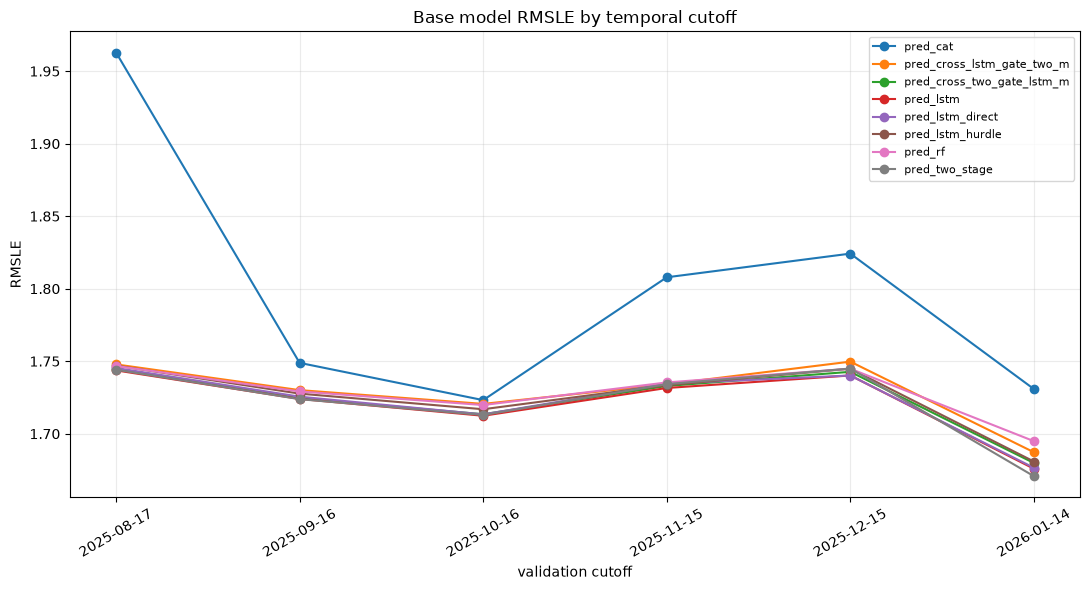

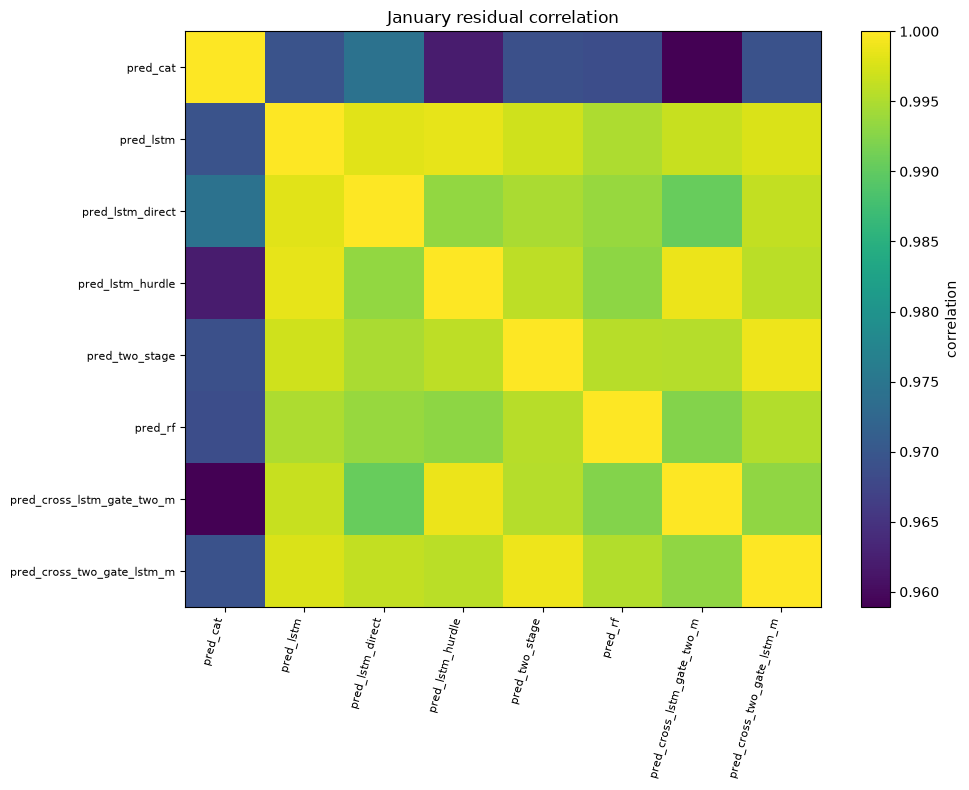

In [18]:
plt.figure(figsize=(11, 6))

for model_name, group in quality.groupby("model"):
    group = group.set_index("cutoff").reindex(OOF_VALID_CUTOFFS).reset_index()

    plt.plot(
        group["cutoff"],
        group["rmsle"],
        marker="o",
        label=model_name,
    )

plt.xlabel("validation cutoff")
plt.ylabel("RMSLE")
plt.title("Base model RMSLE by temporal cutoff")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "base_rmsle_by_cutoff.png", dpi=160)
plt.show()


plt.figure(figsize=(10, 8))

matrix = residual_corr.to_numpy()
image = plt.imshow(matrix, aspect="auto")

plt.colorbar(image, label="correlation")

plt.xticks(
    range(len(residual_corr.columns)),
    residual_corr.columns,
    rotation=75,
    ha="right",
    fontsize=8,
)

plt.yticks(
    range(len(residual_corr.index)),
    residual_corr.index,
    fontsize=8,
)

plt.title("January residual correlation")
plt.tight_layout()
plt.savefig(PLOT_DIR / "jan_residual_correlation.png", dpi=160)
plt.show()

### Что видно на графиках

**Base RMSLE.**

CatBoost direct заметно слабее остальных -- особенно August (`1.9629`), November (`1.8079`) и December (`1.8242`). Самые сильные основные base -- LSTM и two-stage. На January лучший standalone здесь -- two-stage `1.670756`, LSTM -- `1.675888`.

RF слабее LSTM/two-stage, но остается достаточно близко, чтобы потенциально дать diversity.

**Residual correlation.**

Корреляции высокие -- примерно `0.959-0.999`. Это главный ограничитель stacking: модели в целом ошибаются похоже.

Самый отличающийся residual pattern -- у CatBoost. Поэтому даже при плохом standalone RMSLE он теоретически может дать meta небольшой корректирующий сигнал. LSTM / two-stage / их компоненты очень сильно коррелированы -- большого gain только от их линейной склейки ждать не стоит.

## Meta features

Из level-1 OOF достраиваю 22 meta-feature.

Meta-model не получает `Prepared_data` напрямую -- только predictions, gates, cross-hurdle и disagreement.

Это специально ограничивает capacity level-2 и снижает риск переобучения на шести cutoff.

In [19]:
def add_meta_features(frame):
    frame = frame.copy()

    pred_cols = [
        col
        for col in frame.columns
        if col.startswith("pred_")
    ]

    values = frame[pred_cols].to_numpy(dtype=np.float64)

    frame["meta_mean"] = values.mean(axis=1)
    frame["meta_std"] = values.std(axis=1)
    frame["meta_min"] = values.min(axis=1)
    frame["meta_max"] = values.max(axis=1)
    frame["meta_range"] = frame["meta_max"] - frame["meta_min"]

    frame["meta_lstm_minus_cat"] = (
        frame["pred_lstm"] - frame["pred_cat"]
    )

    frame["meta_lstm_minus_two_stage"] = (
        frame["pred_lstm"] - frame["pred_two_stage"]
    )

    frame["meta_cat_minus_two_stage"] = (
        frame["pred_cat"] - frame["pred_two_stage"]
    )

    if "pred_rf" in frame.columns:
        frame["meta_rf_minus_mean"] = (
            frame["pred_rf"] - frame["meta_mean"]
        )

    if HAS_TWO_STAGE_COMPONENTS:
        frame["meta_gate_mean"] = 0.5 * (
            frame["lstm_gate"] + frame["two_stage_gate"]
        )

        frame["meta_gate_diff"] = (
            frame["lstm_gate"] - frame["two_stage_gate"]
        )

        frame["meta_gate_abs_diff"] = np.abs(
            frame["meta_gate_diff"]
        )

    return frame


oof_meta = add_meta_features(oof)

META_FEATURES = [
    col
    for col in oof_meta.columns
    if (
        col.startswith("pred_")
        or col.startswith("meta_")
        or col in ["lstm_gate", "two_stage_gate"]
    )
]

BLEND_FEATURES = [
    col
    for col in [
        "pred_cat",
        "pred_lstm",
        "pred_lstm_direct",
        "pred_lstm_hurdle",
        "pred_two_stage",
        "pred_rf",
        "pred_cross_lstm_gate_two_m",
        "pred_cross_two_gate_lstm_m",
    ]
    if col in oof_meta.columns
]

print("meta features:", len(META_FEATURES))
print("blend features:", BLEND_FEATURES)

meta features: 22
blend features: ['pred_cat', 'pred_lstm', 'pred_lstm_direct', 'pred_lstm_hurdle', 'pred_two_stage', 'pred_rf', 'pred_cross_lstm_gate_two_m', 'pred_cross_two_gate_lstm_m']


## Meta-CV

Перебираю маленькие level-2 модели:

- LinearRegression;
- positive LinearRegression;
- Ridge;
- ElasticNet;
- constrained convex blend.

Для Ridge / ElasticNet сначала `StandardScaler`.

После проблем с convergence ElasticNet grid оставлен только в нормальной области:

```text
alpha = 0.01 / 0.03 / 0.10
l1_ratio = 0.05 / 0.20
max_iter = 30000
tol = 1e-4
```

Победитель выбирается по четырем temporal meta-fold через `selection_score`, а не только по January.

In [22]:
def fit_predict_meta(kind, params, train, valid):
    X_train = train[META_FEATURES].to_numpy(dtype=np.float64)
    y_train = train["target_log"].to_numpy(dtype=np.float64)
    X_valid = valid[META_FEATURES].to_numpy(dtype=np.float64)

    recency_factor = float(
        params.get("recency_factor", 1.0)
    )

    sample_weight = temporal_meta_weights(
        train,
        recency_factor,
    )

    if kind == "linear":
        model = LinearRegression(n_jobs=-1)

        model.fit(
            X_train,
            y_train,
            sample_weight=sample_weight,
        )

    elif kind == "positive_linear":
        model = LinearRegression(
            positive=True,
            n_jobs=-1,
        )

        model.fit(
            X_train,
            y_train,
            sample_weight=sample_weight,
        )

    elif kind == "ridge":
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=params["alpha"]),
        )

        model.fit(
            X_train,
            y_train,
            ridge__sample_weight=sample_weight,
        )

    elif kind == "elastic":
        model = make_pipeline(
            StandardScaler(),
            ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                max_iter=30000,
                tol=1e-4,
                random_state=42,
            )
        )

        model.fit(
            X_train,
            y_train,
            elasticnet__sample_weight=sample_weight,
        )

    else:
        raise ValueError(kind)

    return np.clip(
        model.predict(X_valid),
        0,
        None,
    ), model


def fit_convex(train, l2=0.0, recency_factor=1.0):
    X = train[BLEND_FEATURES].to_numpy(dtype=np.float64)
    y = train["target_log"].to_numpy(dtype=np.float64)
    sample_weight = temporal_meta_weights(train, recency_factor)

    n_features = X.shape[1]
    prior = np.full(n_features, 1.0 / n_features)

    def objective(weights):
        pred = X @ weights
        mse = np.average((y - pred) ** 2, weights=sample_weight)
        reg = l2 * np.mean((weights - prior) ** 2)
        return mse + reg

    result = minimize(
        objective,
        x0=prior,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n_features,
        constraints=[{
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1.0,
        }],
        options={
            "maxiter": 1000,
            "ftol": 1e-12,
        },
    )

    if not result.success:
        raise RuntimeError(result.message)

    return result.x


META_CANDIDATES = []

for recency_factor in META_RECENCY_FACTORS:
    META_CANDIDATES.append(
        ("linear", {"recency_factor": recency_factor})
    )

    META_CANDIDATES.append(
        ("positive_linear", {"recency_factor": recency_factor})
    )

    for alpha in RIDGE_ALPHAS:
        META_CANDIDATES.append(
            (
                "ridge",
                {
                    "alpha": alpha,
                    "recency_factor": recency_factor,
                },
            )
        )

    for alpha, l1_ratio in ELASTICNET_GRID:
        META_CANDIDATES.append(
            (
                "elastic",
                {
                    "alpha": alpha,
                    "l1_ratio": l1_ratio,
                    "recency_factor": recency_factor,
                },
            )
        )

    for l2 in CONVEX_L2_GRID:
        META_CANDIDATES.append(
            (
                "convex",
                {
                    "l2": l2,
                    "recency_factor": recency_factor,
                },
            )
        )


def evaluate_meta_candidates(frame):
    rows = []

    for kind, params in META_CANDIDATES:
        fold_scores = []
        fold_best_base = []

        for valid_cutoff in META_VALID_CUTOFFS:
            valid_pos = OOF_VALID_CUTOFFS.index(valid_cutoff)
            train_cutoffs = OOF_VALID_CUTOFFS[:valid_pos]

            train = frame[
                frame[CUTOFF_COL].isin(train_cutoffs)
            ].copy()

            valid = frame[
                frame[CUTOFF_COL] == valid_cutoff
            ].copy()

            if kind == "convex":
                weights = fit_convex(
                    train,
                    l2=params["l2"],
                    recency_factor=params["recency_factor"],
                )

                pred = np.clip(
                    valid[BLEND_FEATURES].to_numpy(dtype=np.float64) @ weights,
                    0,
                    None,
                )

            else:
                pred, _ = fit_predict_meta(
                    kind,
                    params,
                    train,
                    valid,
                )

            score = float(
                np.sqrt(
                    mean_squared_error(
                        valid["target_log"],
                        pred,
                    )
                )
            )

            best_base = min(
                float(
                    np.sqrt(
                        mean_squared_error(
                            valid["target_log"],
                            np.clip(valid[col], 0, None),
                        )
                    )
                )
                for col in BLEND_FEATURES
            )

            fold_scores.append(score)
            fold_best_base.append(best_base)

        fold_scores = np.asarray(
            fold_scores,
            dtype=np.float64,
        )

        fold_best_base = np.asarray(
            fold_best_base,
            dtype=np.float64,
        )

        mean_score = float(fold_scores.mean())
        std_score = float(fold_scores.std())
        worst_score = float(fold_scores.max())
        worst_gap = float((fold_scores - fold_best_base).max())

        selection_score = (
            mean_score
            + 0.35 * std_score
            + 0.20 * max(worst_gap, 0.0)
        )

        rows.append({
            "kind": kind,
            "params": json.dumps(params, sort_keys=True),
            "oct_rmsle": fold_scores[0],
            "nov_rmsle": fold_scores[1],
            "dec_rmsle": fold_scores[2],
            "jan_rmsle": fold_scores[3],
            "mean_rmsle": mean_score,
            "std_rmsle": std_score,
            "worst_rmsle": worst_score,
            "worst_gap_vs_best_base": worst_gap,
            "selection_score": selection_score,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["selection_score", "mean_rmsle"],
            ignore_index=True,
        )
    )


meta_cv = evaluate_meta_candidates(oof_meta)
display(meta_cv.head(25))

BEST_META_KIND = meta_cv.iloc[0]["kind"]
BEST_META_PARAMS = json.loads(meta_cv.iloc[0]["params"])

print("BEST META:", BEST_META_KIND, BEST_META_PARAMS)

,kind,params,oct_rmsle,nov_rmsle,dec_rmsle,jan_rmsle,mean_rmsle,std_rmsle,worst_rmsle,worst_gap_vs_best_base,selection_score
0,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711364,1.732402,1.738341,1.672087,1.713548,0.025951,1.738341,0.001331,1.722898
1,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711367,1.732434,1.738630,1.672112,1.713636,0.026017,1.738630,0.001355,1.723013
2,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.2, ""recency_fact...",1.711418,1.732353,1.738330,1.672704,1.713701,0.025693,1.738330,0.001948,1.723084
3,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.05, ""recency_fac...",1.711425,1.732367,1.738423,1.672598,1.713703,0.025760,1.738423,0.001842,1.723088
4,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711370,1.732455,1.738919,1.672087,1.713708,0.026100,1.738919,0.001331,1.723109
5,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.05, ""recency_fac...",1.711492,1.732333,1.738280,1.672929,1.713758,0.025586,1.738280,0.002172,1.723148
6,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711375,1.732473,1.739292,1.672006,1.713786,0.026226,1.739292,0.001249,1.723215
7,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.05, ""recency_fac...",1.711429,1.732378,1.738709,1.672711,1.713807,0.025785,1.738709,0.001955,1.723222
8,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.2, ""recency_fact...",1.711422,1.732365,1.738612,1.672871,1.713818,0.025696,1.738612,0.002114,1.723234
9,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.05, ""recency_fac...",1.711502,1.732339,1.738565,1.673163,1.713892,0.025562,1.738565,0.002406,1.723320


BEST META: elastic {'alpha': 0.03, 'l1_ratio': 0.2, 'recency_factor': 1.0}


,cutoff,selected_meta,lstm,best_base
0,2025-10-16,1.711364,1.712406,1.712406
1,2025-11-15,1.732402,1.731563,1.731563
2,2025-12-15,1.738341,1.740193,1.740167
3,2026-01-14,1.672087,1.675888,1.670756


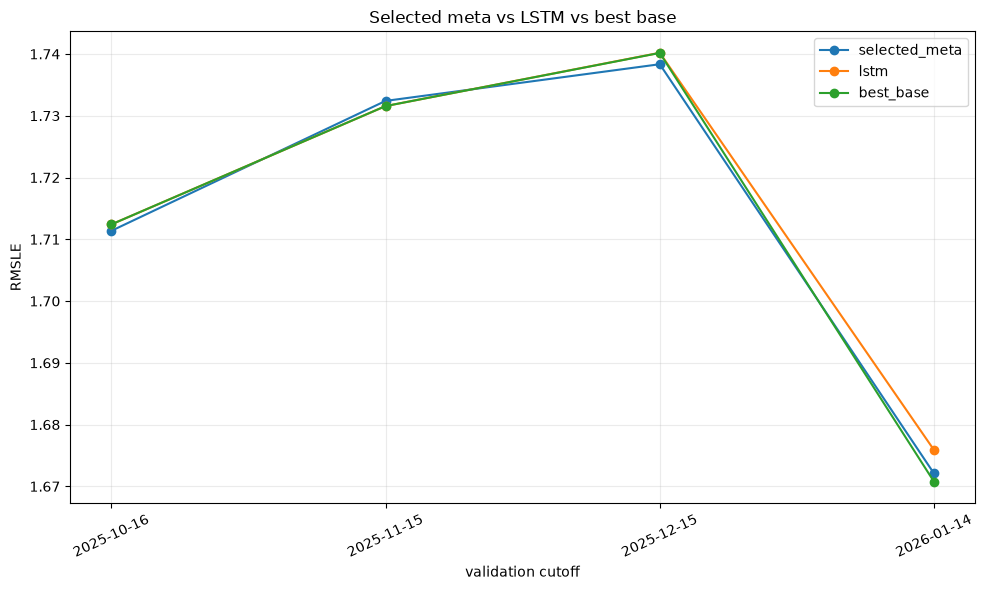

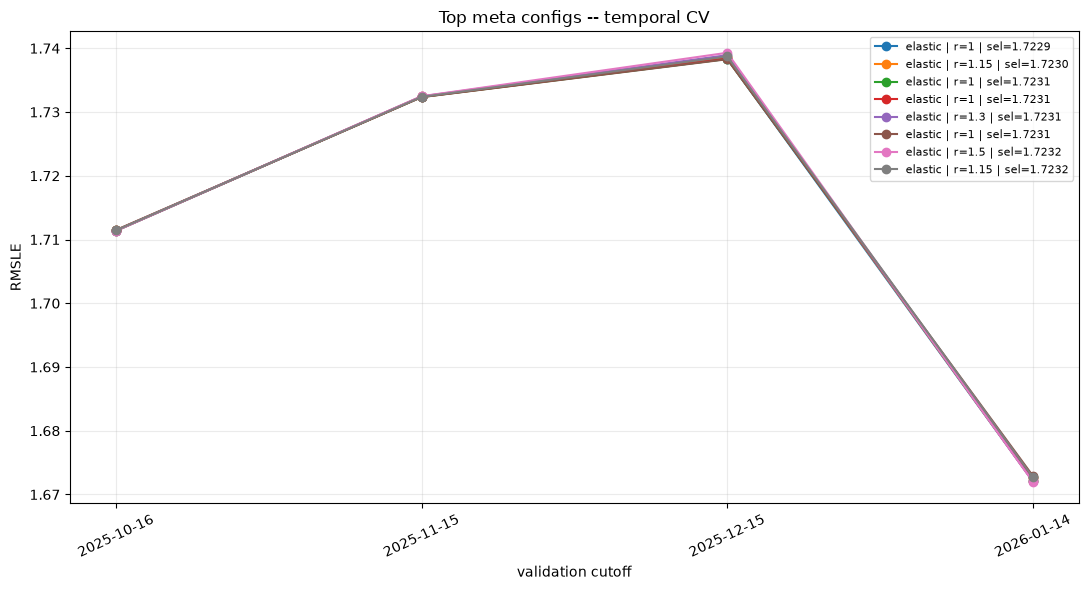

In [23]:
selected_rows = []

for valid_cutoff in META_VALID_CUTOFFS:
    valid_pos = OOF_VALID_CUTOFFS.index(valid_cutoff)
    train_cutoffs = OOF_VALID_CUTOFFS[:valid_pos]

    train = oof_meta[
        oof_meta[CUTOFF_COL].isin(train_cutoffs)
    ].copy()

    valid = oof_meta[
        oof_meta[CUTOFF_COL] == valid_cutoff
    ].copy()

    if BEST_META_KIND == "convex":
        weights = fit_convex(
            train,
            l2=BEST_META_PARAMS["l2"],
            recency_factor=BEST_META_PARAMS["recency_factor"],
        )

        selected_pred = np.clip(
            valid[BLEND_FEATURES].to_numpy(dtype=np.float64) @ weights,
            0,
            None,
        )

    else:
        selected_pred, _ = fit_predict_meta(
            BEST_META_KIND,
            BEST_META_PARAMS,
            train,
            valid,
        )

    selected_score = float(
        np.sqrt(
            mean_squared_error(
                valid["target_log"],
                selected_pred,
            )
        )
    )

    lstm_score = float(
        np.sqrt(
            mean_squared_error(
                valid["target_log"],
                np.clip(valid["pred_lstm"], 0, None),
            )
        )
    )

    best_base_score = min(
        float(
            np.sqrt(
                mean_squared_error(
                    valid["target_log"],
                    np.clip(valid[col], 0, None),
                )
            )
        )
        for col in BLEND_FEATURES
    )

    selected_rows.append({
        "cutoff": valid_cutoff,
        "selected_meta": selected_score,
        "lstm": lstm_score,
        "best_base": best_base_score,
    })

selected_temporal = pd.DataFrame(selected_rows)
display(selected_temporal)


plt.figure(figsize=(10, 6))

for col in ["selected_meta", "lstm", "best_base"]:
    plt.plot(
        selected_temporal["cutoff"],
        selected_temporal[col],
        marker="o",
        label=col,
    )

plt.xlabel("validation cutoff")
plt.ylabel("RMSLE")
plt.title("Selected meta vs LSTM vs best base")
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "selected_meta_vs_bases.png", dpi=160)
plt.show()


score_cols = [
    "oct_rmsle",
    "nov_rmsle",
    "dec_rmsle",
    "jan_rmsle",
]

top_meta = meta_cv.head(8).copy()

plt.figure(figsize=(11, 6))

for _, row in top_meta.iterrows():
    params = json.loads(row["params"])

    label = (
        f"{row['kind']} | r={params.get('recency_factor', 1.0):g} "
        f"| sel={row['selection_score']:.4f}"
    )

    plt.plot(
        META_VALID_CUTOFFS,
        [row[col] for col in score_cols],
        marker="o",
        label=label,
    )

plt.xlabel("validation cutoff")
plt.ylabel("RMSLE")
plt.title("Top meta configs -- temporal CV")
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "meta_top_configs_temporal.png", dpi=160)
plt.show()

### Что видно на meta-CV

Selected ElasticNet против LSTM:

```text
Oct: 1.711364 vs 1.712406 -- лучше на 0.001042
Nov: 1.732402 vs 1.731563 -- хуже  на 0.000839
Dec: 1.738341 vs 1.740193 -- лучше на 0.001852
Jan: 1.672087 vs 1.675888 -- лучше на 0.003801
```

Среднее по четырем meta-fold:

```text
LSTM          1.715013
selected meta 1.713549
gain          0.001464
```

То есть stack улучшает LSTM на 3 из 4 месяцев и особенно хорошо выглядит на January. Это нормальный результат, но не огромный -- residuals base models слишком коррелированы.

На втором графике top-конфиги почти лежат друг на друге. Это хорошо: лучший ElasticNet не выглядит случайным острым minimum. `recency_factor=1.0` победил -- дополнительный вес свежим cutoff не помог.

## Final meta fit

Hyperparameters уже выбраны.

Теперь fit выбранной meta-model на всех шести OOF cutoff.

Параллельно fit самого безопасного constrained convex blend -- он нужен как отдельный submission-кандидат.

In [24]:
def fit_final_meta(kind, params, frame):
    X = frame[META_FEATURES].to_numpy(dtype=np.float64)
    y = frame["target_log"].to_numpy(dtype=np.float64)

    recency_factor = float(
        params.get("recency_factor", 1.0)
    )

    sample_weight = temporal_meta_weights(
        frame,
        recency_factor,
    )

    if kind == "convex":
        return {
            "kind": "convex",
            "weights": fit_convex(
                frame,
                l2=params["l2"],
                recency_factor=recency_factor,
            ),
        }

    if kind == "linear":
        model = LinearRegression(n_jobs=-1)

        model.fit(
            X,
            y,
            sample_weight=sample_weight,
        )

        return model

    if kind == "positive_linear":
        model = LinearRegression(
            positive=True,
            n_jobs=-1,
        )

        model.fit(
            X,
            y,
            sample_weight=sample_weight,
        )

        return model

    if kind == "ridge":
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=params["alpha"]),
        )

        model.fit(
            X,
            y,
            ridge__sample_weight=sample_weight,
        )

        return model

    if kind == "elastic":
        model = make_pipeline(
            StandardScaler(),
            ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                max_iter=10000,
                random_state=42,
            ),
        )

        model.fit(
            X,
            y,
            elasticnet__sample_weight=sample_weight,
        )

        return model

    raise ValueError(kind)


final_meta = fit_final_meta(
    BEST_META_KIND,
    BEST_META_PARAMS,
    oof_meta,
)

best_convex_row = (
    meta_cv[
        meta_cv["kind"] == "convex"
    ]
    .sort_values("selection_score")
    .iloc[0]
)

BEST_CONVEX_PARAMS = json.loads(
    best_convex_row["params"]
)

final_convex = fit_final_meta(
    "convex",
    BEST_CONVEX_PARAMS,
    oof_meta,
)

print("selected:", BEST_META_KIND, BEST_META_PARAMS)
print("best convex:", BEST_CONVEX_PARAMS)

selected: elastic {'alpha': 0.03, 'l1_ratio': 0.2, 'recency_factor': 1.0}
best convex: {'l2': 0.0, 'recency_factor': 1.0}


,importance
pred_lstm_direct,0.171260
pred_lstm,0.163261
pred_two_stage,0.162734
pred_cross_two_gate_lstm_m,0.159249
pred_lstm_hurdle,0.153763
meta_mean,0.152221
meta_min,0.143612
pred_cross_lstm_gate_two_m,0.141220
pred_rf,0.126598
pred_cat,0.100345


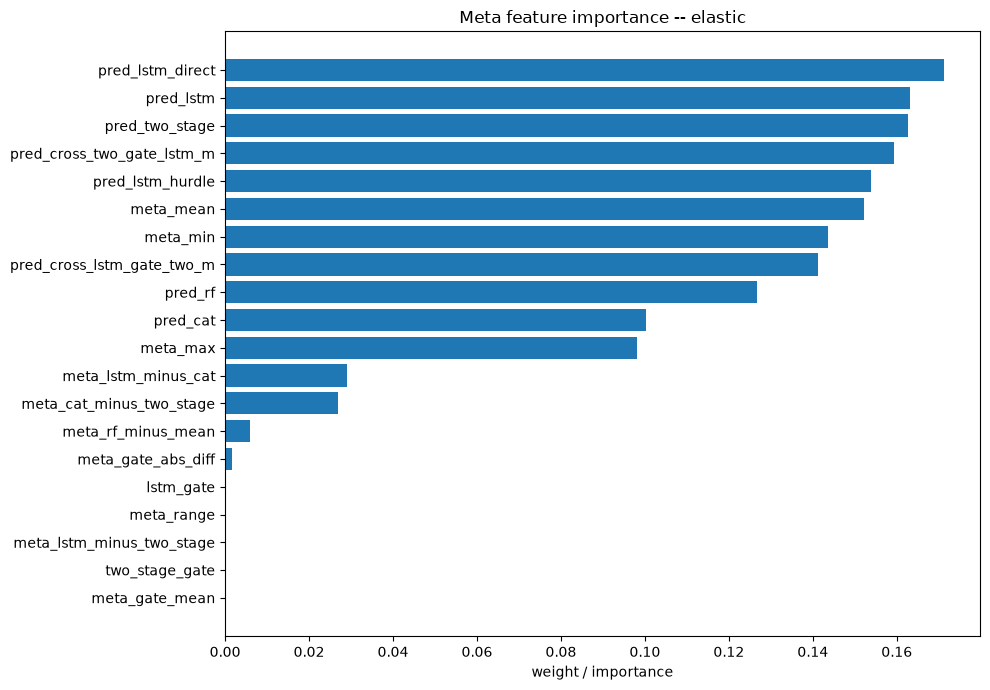

In [25]:
if BEST_META_KIND == "convex":
    importance = pd.Series(
        final_meta["weights"],
        index=BLEND_FEATURES,
        name="importance",
    )

elif hasattr(final_meta, "named_steps"):
    estimator = list(
        final_meta.named_steps.values()
    )[-1]

    importance = pd.Series(
        np.abs(estimator.coef_),
        index=META_FEATURES,
        name="importance",
    )

else:
    importance = pd.Series(
        np.abs(final_meta.coef_),
        index=META_FEATURES,
        name="importance",
    )

importance = importance.sort_values(ascending=False)
display(importance.head(20).to_frame())

top_importance = importance.head(20).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top_importance.index, top_importance.values)
plt.xlabel("weight / importance")
plt.title(f"Meta feature importance -- {BEST_META_KIND}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "meta_feature_importance.png", dpi=160)
plt.show()

### Что видно по meta importance

Для ElasticNet здесь показан **модуль коэффициента после StandardScaler**, а не обычный blend weight.

Главные сигналы:

- `pred_lstm_direct`;
- `pred_lstm`;
- `pred_two_stage`;
- cross `two-stage gate * LSTM magnitude`;
- `pred_lstm_hurdle`;
- агрегаты `meta_mean` / `meta_min`.

RF и CatBoost тоже используются, но слабее.

Отдельные `lstm_gate` / `two_stage_gate` почти занулились. Gate полезнее не сам по себе, а внутри hurdle/cross predictions.

Это ожидаемо -- meta в основном корректирует уровень прогноза, а не строит новую модель покупки с нуля.

## Final base predictions

Обучаю / загружаю final level-1 predictions на inference cutoff `2026-02-13`.

Важно -- final model spec совпадает с OOF:

- CatBoost -- тот же config;
- LSTM -- seed 42, 6 epochs;
- two-stage -- та же nested calibration;
- RF -- тот же config.

Отдельно ищу лучший двухсидовый `lstm_hurdle_v4_robust.csv` -- он используется только как anchor для safe blends.

In [26]:
def final_cat_direct():
    path = TEST_DIR / "cat_direct.parquet"
    signature = stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "cat_direct_final",
        "params": CAT_DIRECT_PARAMS,
        "feature_schema": FEATURE_SCHEMA_HASH,
    })

    cached = load_valid_cache(
        path,
        INFERENCE_CUTOFF,
        ["pred_log"],
        signature,
    )

    if cached is not None:
        return cached

    train = prepared[
        prepared[CUTOFF_COL].isin(LABELED_CUTOFFS)
        & np.isfinite(prepared[TARGET_COL])
    ].copy()

    test = cutoff_frame(
        INFERENCE_CUTOFF,
        with_target=False,
    )

    train_cat = train[CAT_FEATURES].copy()
    test_cat = test[CAT_FEATURES].copy()

    train_cat[ID_COL] = train_cat[ID_COL].astype(str)
    test_cat[ID_COL] = test_cat[ID_COL].astype(str)

    model = CatBoostRegressor(**CAT_DIRECT_PARAMS)

    model.fit(
        train_cat,
        np.log1p(train[TARGET_COL].to_numpy(dtype=np.float32)),
        cat_features=[ID_COL],
    )

    pred_log = np.clip(
        model.predict(test_cat),
        0,
        None,
    )

    out = pd.DataFrame({
        ID_COL: test[ID_COL].to_numpy(),
        "pred_log": pred_log,
    })

    save_pred(
        path,
        out,
        cutoff=INFERENCE_CUTOFF,
        signature=signature,
        metadata={
            "model": "cat_direct_final",
            "params": CAT_DIRECT_PARAMS,
        },
    )

    del model, train, test, train_cat, test_cat
    gc.collect()

    return out


def final_lstm_components():
    path = TEST_DIR / "lstm_seed42_components.parquet"

    signature = stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "lstm_v4_final",
        "seed": LSTM_STACK_SEED,
        "epochs": LSTM_STACK_EPOCHS,
        "model_kwargs": MODEL_KWARGS,
    })

    cached = load_valid_cache(
        path,
        INFERENCE_CUTOFF,
        [
            "pred_log",
            "direct_log",
            "hurdle_log",
            "gate_prob",
            "positive_log",
        ],
        signature,
    )

    if cached is not None:
        return cached

    checkpoint_path = (
        MODEL_DIR
        / f"seed_{LSTM_STACK_SEED}"
        / "model.pt"
    )

    if not checkpoint_path.exists():
        checkpoint_path = MODEL_DIR / "model.pt"

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            "Final LSTM seed42 weights not found"
        )

    checkpoint = safe_torch_load_stack(
        checkpoint_path,
        map_location=DEVICE,
    )

    model = JointHurdleLSTM(
        **checkpoint.get("model_kwargs", MODEL_KWARGS)
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["state_dict"],
        strict=True,
    )

    static_payload = safe_torch_load_stack(
        MODEL_DIR / "static_stats.pt",
        map_location="cpu",
    )

    static_stats = (
        static_payload["mean"].float(),
        static_payload["std"].float(),
    )

    known_mask = known_user_mask_from_cutoffs(
        LABELED_CUTOFFS
    )

    users, pred, _ = predict_model(
        model,
        INFERENCE_CUTOFF,
        static_stats,
        known_mask,
        with_target=False,
    )

    out = pd.DataFrame({
        ID_COL: users,
        "pred_log": np.clip(pred["pred_log"], 0, None),
        "direct_log": np.clip(pred["direct_log"], 0, None),
        "hurdle_log": np.clip(pred["hurdle_log"], 0, None),
        "gate_prob": np.clip(pred["gate_prob"], 0, 1),
        "positive_log": np.clip(pred["positive_log"], 0, None),
    })

    save_pred(
        path,
        out,
        cutoff=INFERENCE_CUTOFF,
        signature=signature,
        metadata={
            "model": "lstm_v4_final",
            "seed": LSTM_STACK_SEED,
            "epochs": LSTM_STACK_EPOCHS,
        },
    )

    del model
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return out


def final_two_stage():
    if EXACT_TWO_STAGE_OOF is not None and TWO_STAGE_FINAL_PATH is not None:
        print("final two-stage -- exact teammate submission")
        return load_submission_pred_log(
            TWO_STAGE_FINAL_PATH
        )

    path = TEST_DIR / "two_stage_trained.parquet"

    signature = stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "two_stage_final",
        "params": TWO_STAGE_SPEC,
        "calibration": "nested_previous_cutoff_v1",
    })

    required = [
        "pred_log",
        "p_nonzero",
        "positive_log",
        "gamma",
        "scale",
    ]

    cached = load_valid_cache(
        path,
        INFERENCE_CUTOFF,
        required,
        signature,
    )

    if cached is not None:
        return cached

    out = run_two_stage_worker(
        path,
        LABELED_CUTOFFS,
        inference_cutoff=INFERENCE_CUTOFF,
    )

    valid, reason = validate_prediction_frame(
        out,
        INFERENCE_CUTOFF,
        required,
    )

    if not valid:
        raise RuntimeError(
            f"Invalid final two-stage output: {reason}"
        )

    save_pred(
        path,
        out,
        cutoff=INFERENCE_CUTOFF,
        signature=signature,
        metadata={
            "model": "two_stage_final",
            "spec_source": TWO_STAGE_SPEC["source"],
            "calibration": "nested_previous_cutoff_v1",
        },
    )

    return out


def final_rf():
    if not USE_RF:
        return None

    path = TEST_DIR / "rf.parquet"

    signature = stable_hash({
        "cache_version": CACHE_VERSION,
        "model": "rf_final",
        "params": RF_PARAMS,
        "feature_schema": FEATURE_SCHEMA_HASH,
    })

    cached = load_valid_cache(
        path,
        INFERENCE_CUTOFF,
        ["pred_log"],
        signature,
    )

    if cached is not None:
        return cached

    train = prepared[
        prepared[CUTOFF_COL].isin(LABELED_CUTOFFS)
        & np.isfinite(prepared[TARGET_COL])
    ].copy()

    test = cutoff_frame(
        INFERENCE_CUTOFF,
        with_target=False,
    )

    medians = train[TAB_FEATURES].median(axis=0)

    X_train = (
        train[TAB_FEATURES]
        .fillna(medians)
        .to_numpy(dtype=np.float32)
    )

    X_test = (
        test[TAB_FEATURES]
        .fillna(medians)
        .to_numpy(dtype=np.float32)
    )

    y_log = np.log1p(
        train[TARGET_COL].to_numpy(dtype=np.float32)
    )

    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_train, y_log)

    pred_log = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    out = pd.DataFrame({
        ID_COL: test[ID_COL].to_numpy(),
        "pred_log": pred_log,
    })

    save_pred(
        path,
        out,
        cutoff=INFERENCE_CUTOFF,
        signature=signature,
        metadata={
            "model": "rf_final",
            "params": RF_PARAMS,
        },
    )

    del model, train, test, X_train, X_test
    gc.collect()

    return out


cat_test = final_cat_direct()
two_stage_test = final_two_stage()
lstm_test = final_lstm_components()
rf_test = final_rf()

two-stage subprocess: final 2026-02-13 n_jobs=-1
SAVED two-stage final: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max/test_level1/two_stage_trained.parquet rows=250000 gamma=1.145772 scale=0.959632


## Final level-1 + submissions

Собираю February prediction всех base models в те же 22 meta-feature и считаю четыре submission.

Все blend делаются в `log1p`-пространстве, потом применяется `expm1`.

In [27]:
sample = pd.read_csv(SAMPLE_SUBMIT_PATH)
level1_test = sample[[ID_COL]].copy()

level1_test = level1_test.merge(
    cat_test.rename(
        columns={"pred_log": "pred_cat"}
    ),
    on=ID_COL,
    how="left",
    validate="one_to_one",
)

level1_test = level1_test.merge(
    lstm_test.rename(
        columns={
            "pred_log": "pred_lstm",
            "direct_log": "pred_lstm_direct",
            "hurdle_log": "pred_lstm_hurdle",
            "gate_prob": "lstm_gate",
            "positive_log": "lstm_positive",
        }
    ),
    on=ID_COL,
    how="left",
    validate="one_to_one",
)

two_stage_merge = two_stage_test.rename(
    columns={"pred_log": "pred_two_stage"}
)

if HAS_TWO_STAGE_COMPONENTS:
    two_stage_merge = two_stage_merge.rename(
        columns={
            "p_nonzero": "two_stage_gate",
            "positive_log": "two_stage_positive",
        }
    )

level1_test = level1_test.merge(
    two_stage_merge,
    on=ID_COL,
    how="left",
    validate="one_to_one",
)

if USE_RF:
    level1_test = level1_test.merge(
        rf_test.rename(
            columns={"pred_log": "pred_rf"}
        ),
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

if HAS_TWO_STAGE_COMPONENTS and USE_CROSS_HURDLE:
    level1_test["pred_cross_lstm_gate_two_m"] = (
        level1_test["lstm_gate"]
        * level1_test["two_stage_positive"]
    )

    level1_test["pred_cross_two_gate_lstm_m"] = (
        level1_test["two_stage_gate"]
        * level1_test["lstm_positive"]
    )

level1_test = add_meta_features(level1_test)

missing = level1_test[META_FEATURES].isna().sum()
missing = missing[missing > 0]

if len(missing):
    raise AssertionError(missing.to_dict())


def predict_meta(model, kind, frame):
    if kind == "convex":
        return np.clip(
            frame[BLEND_FEATURES].to_numpy(dtype=np.float64)
            @ model["weights"],
            0,
            None,
        )

    return np.clip(
        model.predict(
            frame[META_FEATURES].to_numpy(dtype=np.float64)
        ),
        0,
        None,
    )


selected_log = predict_meta(
    final_meta,
    BEST_META_KIND,
    level1_test,
)

convex_log = predict_meta(
    final_convex,
    "convex",
    level1_test,
)

lstm_proxy_log = level1_test[
    "pred_lstm"
].to_numpy(dtype=np.float64)

exact_lstm_path = find_submission([
    "lstm_hurdle_v4_robust.csv",
])

if exact_lstm_path is not None:
    exact_lstm = load_submission_pred_log(
        exact_lstm_path
    )

    exact_lstm = sample[[ID_COL]].merge(
        exact_lstm,
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    lstm_anchor_log = exact_lstm[
        "pred_log"
    ].to_numpy(dtype=np.float64)

else:
    lstm_anchor_log = lstm_proxy_log

safe70_log = (
    0.70 * lstm_anchor_log
    + 0.30 * selected_log
)

safe85_log = (
    0.85 * lstm_anchor_log
    + 0.15 * selected_log
)

submission_specs = {
    "mega_stack_selected.csv": selected_log,
    "mega_stack_convex.csv": convex_log,
    "mega_stack_safe70.csv": safe70_log,
    "mega_stack_safe85.csv": safe85_log,
}

saved_submissions = {}

for filename, pred_log in submission_specs.items():
    prediction = np.expm1(
        np.clip(pred_log, 0, None)
    )

    submission = sample.copy()
    submission["predict"] = prediction

    if not np.isfinite(
        submission["predict"]
    ).all():
        raise AssertionError(filename)

    if (
        submission["predict"] < 0
    ).any():
        raise AssertionError(filename)

    path = SUBMISSION_DIR / filename

    submission.to_csv(
        path,
        index=False,
    )

    saved_submissions[
        filename
    ] = str(path)

level1_test.to_parquet(
    STACK_DIR / "level1_test.parquet",
    index=False,
)

print("saved submissions:")

for name, path in saved_submissions.items():
    print(name, "->", path)

saved submissions:
mega_stack_selected.csv -> /Users/pinta/Dev/E-CUP-2026/submissions/mega_stack_selected.csv
mega_stack_convex.csv -> /Users/pinta/Dev/E-CUP-2026/submissions/mega_stack_convex.csv
mega_stack_safe70.csv -> /Users/pinta/Dev/E-CUP-2026/submissions/mega_stack_safe70.csv
mega_stack_safe85.csv -> /Users/pinta/Dev/E-CUP-2026/submissions/mega_stack_safe85.csv


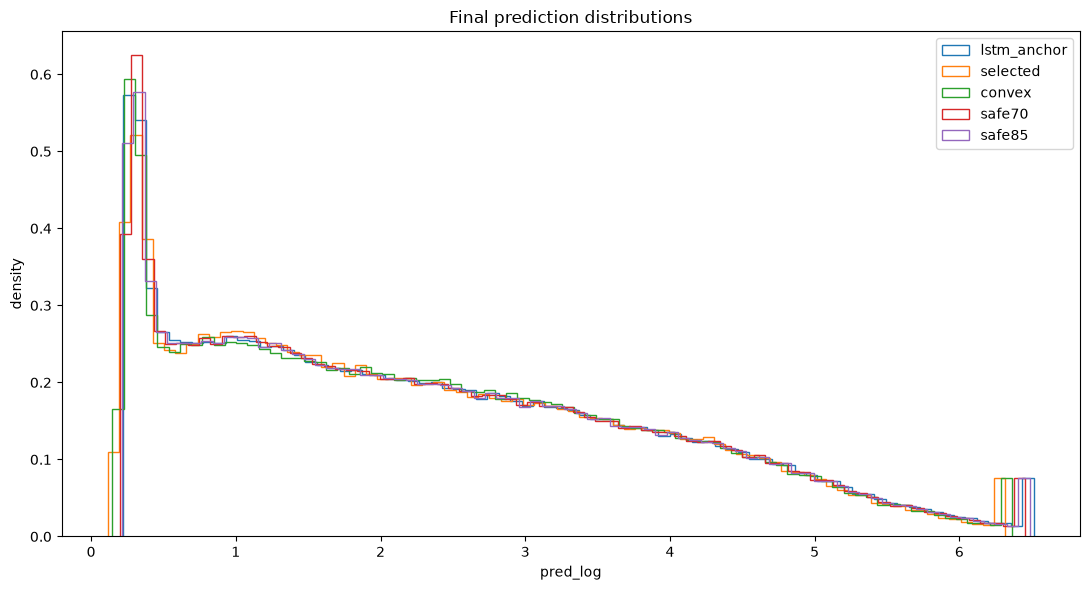

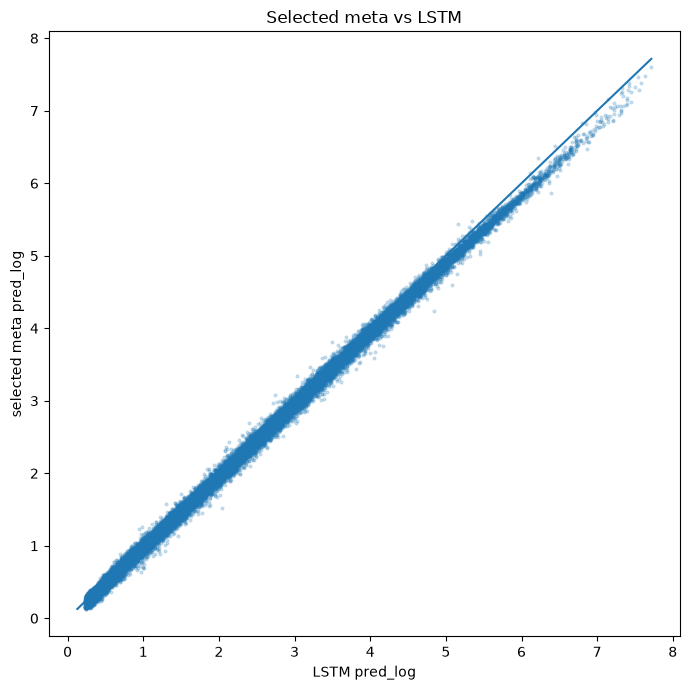

In [28]:
plt.figure(figsize=(11, 6))

for name, values in {
    "lstm_anchor": lstm_anchor_log,
    "selected": selected_log,
    "convex": convex_log,
    "safe70": safe70_log,
    "safe85": safe85_log,
}.items():
    upper = np.quantile(values, 0.995)

    plt.hist(
        np.clip(values, 0, upper),
        bins=80,
        histtype="step",
        density=True,
        label=name,
    )

plt.xlabel("pred_log")
plt.ylabel("density")
plt.title("Final prediction distributions")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "final_prediction_distributions.png", dpi=160)
plt.show()


sample_size = min(
    30000,
    len(lstm_anchor_log),
)

rng = np.random.default_rng(42)

indices = rng.choice(
    len(lstm_anchor_log),
    size=sample_size,
    replace=False,
)

plt.figure(figsize=(7, 7))

plt.scatter(
    lstm_anchor_log[indices],
    selected_log[indices],
    s=4,
    alpha=0.20,
)

low = min(
    float(lstm_anchor_log[indices].min()),
    float(selected_log[indices].min()),
)

high = max(
    float(lstm_anchor_log[indices].max()),
    float(selected_log[indices].max()),
)

plt.plot([low, high], [low, high])
plt.xlabel("LSTM pred_log")
plt.ylabel("selected meta pred_log")
plt.title("Selected meta vs LSTM")
plt.tight_layout()
plt.savefig(PLOT_DIR / "selected_vs_lstm_scatter.png", dpi=160)
plt.show()

### Что видно на final predictions

**Distribution.**

Все четыре stack-варианта остаются близки к LSTM -- нет явного сдвига распределения или странного нового хвоста.

Спайк справа -- технический эффект графика: каждое распределение перед histogram обрезается по своему `99.5%` quantile.

**Selected meta vs LSTM.**

Облако почти лежит на диагонали. Значит ElasticNet делает небольшую correction к сильной LSTM, а не полностью переписывает prediction.

На больших `pred_log` correction заметнее и чаще немного уменьшает prediction. Это выглядит адекватно, но одновременно подтверждает ограничение ансамбля -- selected и LSTM очень похожи.

## Artifacts

Сохраняю:

- base quality;
- January residual correlation;
- meta-CV table;
- level-1 OOF;
- final meta-model;
- полный config;
- пути ко всем submission.

Этого достаточно, чтобы потом воспроизвести результат без повторного ручного разбора notebook.

In [29]:
quality.to_csv(
    STACK_DIR / "base_quality.csv",
    index=False,
)

residual_corr.to_csv(
    STACK_DIR / "jan_residual_corr.csv",
)

meta_cv.to_csv(
    STACK_DIR / "meta_cv.csv",
    index=False,
)

oof_meta.to_parquet(
    STACK_DIR / "level1_oof_meta.parquet",
    index=False,
)

if BEST_META_KIND == "convex":
    with open(
        STACK_DIR / "selected_meta.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "kind": "convex",
                "weights": final_meta["weights"].tolist(),
                "features": BLEND_FEATURES,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

else:
    joblib.dump(
        final_meta,
        STACK_DIR / "selected_meta.joblib",
    )

config = {
    "cache_version": CACHE_VERSION,
    "oof_cutoffs": OOF_VALID_CUTOFFS,
    "meta_valid_cutoffs": META_VALID_CUTOFFS,
    "base_models": [
        "catboost_direct",
        "two_stage",
        "lstm_v4_seed42",
        "random_forest" if USE_RF else None,
    ],
    "catboost_params": CAT_DIRECT_PARAMS,
    "two_stage_source": TWO_STAGE_SOURCE,
    "two_stage_params_source": TWO_STAGE_SPEC["source"],
    "two_stage_feature_source": TWO_STAGE_SPEC["feature_source"],
    "two_stage_feature_count": len(TWO_STAGE_SPEC["feature_cols"]),
    "two_stage_exact_oof": str(EXACT_TWO_STAGE_OOF_PATH) if EXACT_TWO_STAGE_OOF_PATH else None,
    "two_stage_exact_final": str(TWO_STAGE_FINAL_PATH) if TWO_STAGE_FINAL_PATH else None,
    "lstm_seed": LSTM_STACK_SEED,
    "lstm_epochs": LSTM_STACK_EPOCHS,
    "rf_params": RF_PARAMS,
    "selected_meta_kind": BEST_META_KIND,
    "selected_meta_params": BEST_META_PARAMS,
    "best_convex_params": BEST_CONVEX_PARAMS,
    "meta_features": META_FEATURES,
    "blend_features": BLEND_FEATURES,
    "saved_submissions": saved_submissions,
}

with open(
    STACK_DIR / "config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("artifacts:", STACK_DIR)
display(meta_cv.head(15))

artifacts: /Users/pinta/Dev/E-CUP-2026/models/temporal_stacking_max


,kind,params,oct_rmsle,nov_rmsle,dec_rmsle,jan_rmsle,mean_rmsle,std_rmsle,worst_rmsle,worst_gap_vs_best_base,selection_score
0,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711364,1.732402,1.738341,1.672087,1.713548,0.025951,1.738341,0.001331,1.722898
1,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711367,1.732434,1.738630,1.672112,1.713636,0.026017,1.738630,0.001355,1.723013
2,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.2, ""recency_fact...",1.711418,1.732353,1.738330,1.672704,1.713701,0.025693,1.738330,0.001948,1.723084
3,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.05, ""recency_fac...",1.711425,1.732367,1.738423,1.672598,1.713703,0.025760,1.738423,0.001842,1.723088
4,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711370,1.732455,1.738919,1.672087,1.713708,0.026100,1.738919,0.001331,1.723109
5,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.05, ""recency_fac...",1.711492,1.732333,1.738280,1.672929,1.713758,0.025586,1.738280,0.002172,1.723148
6,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.2, ""recency_fact...",1.711375,1.732473,1.739292,1.672006,1.713786,0.026226,1.739292,0.001249,1.723215
7,elastic,"{""alpha"": 0.03, ""l1_ratio"": 0.05, ""recency_fac...",1.711429,1.732378,1.738709,1.672711,1.713807,0.025785,1.738709,0.001955,1.723222
8,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.2, ""recency_fact...",1.711422,1.732365,1.738612,1.672871,1.713818,0.025696,1.738612,0.002114,1.723234
9,elastic,"{""alpha"": 0.01, ""l1_ratio"": 0.05, ""recency_fac...",1.711502,1.732339,1.738565,1.673163,1.713892,0.025562,1.738565,0.002406,1.723320


# Итог запуска

## Насколько хороший результат

Локально stack **работает**, но gain умеренный.

Главный selected ElasticNet:

```text
mean temporal RMSLE: 1.713549
mean LSTM RMSLE:     1.715013
gain:                0.001464
```

По месяцам selected лучше LSTM на Oct / Dec / Jan и хуже только на Nov.

Самый интересный сигнал -- January:

```text
LSTM:          1.675888
selected meta: 1.672087
gain:          0.003801
two-stage:     1.670756
```

January -- последний доступный labeled cutoff перед inference, поэтому такой gain выглядит перспективно.

Но до текущего top-5 по public от LSTM нужно `0.004740`. Средний local gain stack меньше этого. Поэтому **top-5 не гарантирован** -- это хороший ensemble improvement, но не магическая кнопка на `-0.005`.

Еще один важный факт -- residual correlation почти везде очень высокая. Именно поэтому gain получается порядка `1e-3`, а не `1e-2`.

---

# Что за четыре submission

## `mega_stack_selected.csv`

Основной submission.

```text
base predictions
-> 22 meta-feature
-> ElasticNet(alpha=0.03, l1_ratio=0.20)
-> final pred_log
```

ElasticNet выбран честной temporal meta-CV.

Плюсы:

- лучший mean score среди проверенных meta-config;
- улучшает LSTM на 3/4 meta-fold;
- January лучше LSTM на `0.003801`;
- это единственный вариант, который непосредственно выбран validation-схемой.

Минус -- linear meta может давать более агрессивные corrections, чем convex blend.

**Если отправлять один файл -- отправлять этот.**

---

## `mega_stack_convex.csv`

Constrained blend.

Ограничения:

```text
weight_i >= 0
sum(weight_i) = 1
```

Best config:

```text
l2=0
recency_factor=1.0
```

Temporal CV:

```text
mean RMSLE ~= 1.714035
```

То есть хуже selected (`1.713549`), но все еще лучше средней LSTM (`1.715013`).

Плюсы:

- не может получить странные большие +/- коэффициенты;
- наиболее интерпретируемый и устойчивый stack;
- хороший sanity-check против ElasticNet.

**Если можно отправить второй файл -- отправлять convex.**

---

## `mega_stack_safe70.csv`

Ручной hedge:

```text
0.70 * best LSTM anchor
+ 0.30 * selected meta
```

Blend делается в `log1p`-пространстве.

Если `lstm_hurdle_v4_robust.csv` найден, anchor -- лучший двухсидовый LSTM submission. Иначе используется seed-42 LSTM prediction.

Плюс -- сохраняет большую часть уже доказанного public качества LSTM, но добавляет correction stack.

Минус -- коэффициент `70/30` **не выбирался temporal CV**, потому что exact two-seed LSTM anchor не имеет полностью симметричного OOF набора.

Это не основной научно выбранный вариант, а страховка.

**Отправлять третьим, если есть submission budget.**

---

## `mega_stack_safe85.csv`

Еще более консервативный hedge:

```text
0.85 * best LSTM anchor
+ 0.15 * selected meta
```

Он должен остаться ближе всего к текущему LSTM `1.650910`.

Плюс -- минимальный риск сильно испортить хороший LSTM.

Минус -- correction очень слабая, поэтому и шанс снять нужные `~0.0047` ниже.

**Отправлять только как четвертый / backup вариант.**

---

# Порядок submission

Если есть несколько попыток:

```text
1. mega_stack_selected.csv
2. mega_stack_convex.csv
3. mega_stack_safe70.csv
4. mega_stack_safe85.csv
```

Если попытка одна -- `mega_stack_selected.csv`.

Почему не safe70 первым -- selected единственный реально победил по temporal meta-CV. Safe blends полезны как hedge, но их коэффициенты не были выбраны на честном OOF exact two-seed anchor.

Если selected на public дает хороший gain -- дальше уже имеет смысл менять сами base models / признаки, а не инфраструктуру stack.